# ROGII Wellbore Geology Prediction
## Notebook 03 – Dataset-Wide Exploratory Data Analysis

### Objectives

- Analyse all training well pairs with suffix-safe well IDs.
- Compare well sizes, prediction-zone lengths and ordinary missingness.
- Validate the intentional `TVT_input` prediction boundary.
- Select criteria-based example wells and compare known vs prediction regions.
- Compare train and test feature distributions without using test targets.
- Assess typewell coverage, prediction-horizon difficulty and outliers.
- Produce evidence for preprocessing, feature engineering and grouped validation.


### 1. Import Libraries

In [29]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
sns.set_theme(style="whitegrid", context="notebook")


### 2. Configure Project Paths

In [30]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_DIR = RAW_DIR / "train"
TEST_DIR = RAW_DIR / "test"

RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_03"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Training directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())
print("Processed directory exists:", PROCESSED_DIR.exists())
print("Results directory:", RESULTS_DIR.resolve())


Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Training directory exists: True
Test directory exists: True
Processed directory exists: True
Results directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_03


### 3. Discover Training Well Pairs

Well IDs are recovered by removing the exact suffixes `__typewell.csv` and
`__horizontal_well.csv`. This avoids trailing underscores produced by naive
`replace("_typewell.csv", "")` on double-underscore filenames.


In [31]:
TYPEWELL_SUFFIX = "__typewell.csv"
HORIZONTAL_SUFFIX = "__horizontal_well.csv"


def extract_well_id(filename: str, suffix: str):
    if filename.endswith(suffix):
        well_id = filename[: -len(suffix)]
        if well_id and not well_id.endswith("_"):
            return well_id
    return None


def build_well_maps(data_dir: Path):
    typewell_files = sorted(data_dir.glob("*_typewell.csv"))
    horizontal_files = sorted(data_dir.glob("*_horizontal_well.csv"))

    typewell_map = {}
    horizontal_map = {}
    malformed = []

    for file in typewell_files:
        well_id = extract_well_id(file.name, TYPEWELL_SUFFIX)
        if well_id is None:
            malformed.append(file.name)
        else:
            typewell_map[well_id] = file

    for file in horizontal_files:
        well_id = extract_well_id(file.name, HORIZONTAL_SUFFIX)
        if well_id is None:
            malformed.append(file.name)
        else:
            horizontal_map[well_id] = file

    typewell_ids = set(typewell_map)
    horizontal_ids = set(horizontal_map)
    complete_ids = sorted(typewell_ids & horizontal_ids)
    unmatched = sorted(
        (typewell_ids - horizontal_ids) | (horizontal_ids - typewell_ids)
    )

    validation = pd.DataFrame(
        [
            {"Metric": "Number of horizontal wells", "Count": len(horizontal_ids)},
            {"Metric": "Number of typewells", "Count": len(typewell_ids)},
            {"Metric": "Number of matched pairs", "Count": len(complete_ids)},
            {
                "Metric": "Number of unmatched files",
                "Count": len(unmatched) + len(malformed),
            },
            {"Metric": "Number of malformed IDs", "Count": len(malformed)},
        ]
    )
    return (
        typewell_files,
        horizontal_files,
        typewell_map,
        horizontal_map,
        complete_ids,
        validation,
        malformed,
        unmatched,
    )


(
    typewell_files,
    horizontal_files,
    typewell_map,
    horizontal_map,
    complete_ids,
    well_id_validation,
    malformed_files,
    unmatched_ids,
) = build_well_maps(TRAIN_DIR)

display(well_id_validation)
well_id_validation.to_csv(TABLES_DIR / "well_id_validation.csv", index=False)

print("Example matched IDs:", complete_ids[:5])
assert all(not well_id.endswith("_") for well_id in complete_ids)
assert len(malformed_files) == 0


,Metric,Count
0,Number of horizontal wells,773
1,Number of typewells,773
2,Number of matched pairs,773
3,Number of unmatched files,0
4,Number of malformed IDs,0


Example matched IDs: ['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4']


### 4. Create Helper Functions

In [32]:
def safe_correlation(first_series, second_series):
    valid_data = pd.DataFrame({
        "first": first_series,
        "second": second_series
    }).dropna()

    if len(valid_data) < 2:
        return np.nan

    if valid_data["first"].nunique() < 2:
        return np.nan

    if valid_data["second"].nunique() < 2:
        return np.nan

    return valid_data.corr().iloc[0, 1]

In [33]:
def calculate_prefix_slope(horizontal_data, known_mask, window):
    visible_data = (
        horizontal_data
        .loc[known_mask, ["MD", "TVT_input"]]
        .dropna()
        .tail(window)
    )

    if len(visible_data) < 2:
        return np.nan

    slope, _ = np.polyfit(
        visible_data["MD"],
        visible_data["TVT_input"],
        1
    )

    return slope

In [34]:
def longest_missing_run(series):
    missing_mask = series.isna().to_numpy()

    longest_run = 0
    current_run = 0

    for is_missing in missing_mask:
        if is_missing:
            current_run += 1
            longest_run = max(longest_run, current_run)
        else:
            current_run = 0

    return longest_run

### 5. Create the Well Summary Function

In [35]:
FORMATION_COLUMNS = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA",
]


def summarize_well(well_id, typewell_map_ref=None, horizontal_map_ref=None):
    typewell_map_ref = typewell_map_ref or typewell_map
    horizontal_map_ref = horizontal_map_ref or horizontal_map

    typewell = pd.read_csv(typewell_map_ref[well_id])
    horizontal = pd.read_csv(horizontal_map_ref[well_id])
    has_target_tvt = "TVT" in horizontal.columns

    known_mask = horizontal["TVT_input"].notna()
    prediction_mask = ~known_mask

    known_positions = np.flatnonzero(known_mask.to_numpy())
    prediction_positions = np.flatnonzero(prediction_mask.to_numpy())

    known_rows = int(known_mask.sum())
    prediction_rows = int(prediction_mask.sum())
    n_rows = len(horizontal)

    if len(prediction_positions) > 0:
        prediction_start_position = int(prediction_positions[0])
        prediction_start_md = float(horizontal.iloc[prediction_start_position]["MD"])
        clean_boundary = bool(
            known_mask.iloc[:prediction_start_position].all()
            and prediction_mask.iloc[prediction_start_position:].all()
        )
        unexpected_internal_gaps = not clean_boundary
    else:
        prediction_start_position = None
        prediction_start_md = np.nan
        clean_boundary = True
        unexpected_internal_gaps = False

    if len(known_positions) > 0:
        last_known_position = int(known_positions[-1])
        last_known_md = float(horizontal.iloc[last_known_position]["MD"])
        last_known_tvt = float(horizontal.iloc[last_known_position]["TVT_input"])
    else:
        last_known_md = np.nan
        last_known_tvt = np.nan

    if has_target_tvt and known_rows > 0:
        tvt_input_matches_tvt = bool(
            np.allclose(
                horizontal.loc[known_mask, "TVT_input"],
                horizontal.loc[known_mask, "TVT"],
            )
        )
    else:
        tvt_input_matches_tvt = False

    typewell_tvt_min = float(typewell["TVT"].min()) if "TVT" in typewell else np.nan
    typewell_tvt_max = float(typewell["TVT"].max()) if "TVT" in typewell else np.nan

    if has_target_tvt:
        horizontal_tvt_min = float(horizontal["TVT"].min())
        horizontal_tvt_max = float(horizontal["TVT"].max())
        final_tvt = float(horizontal["TVT"].iloc[-1])
        if prediction_rows > 0:
            pred_tvt = horizontal.loc[prediction_mask, "TVT"]
            pred_region_tvt_min = float(pred_tvt.min())
            pred_region_tvt_max = float(pred_tvt.max())
        else:
            pred_region_tvt_min = np.nan
            pred_region_tvt_max = np.nan
    else:
        # Test horizontals expose TVT_input / trajectory / GR only.
        horizontal_tvt_min = np.nan
        horizontal_tvt_max = np.nan
        final_tvt = np.nan
        pred_region_tvt_min = np.nan
        pred_region_tvt_max = np.nan

    md_max = float(horizontal["MD"].max())
    prediction_horizon_md = (
        md_max - prediction_start_md
        if pd.notna(prediction_start_md)
        else np.nan
    )
    delta_tvt = (
        final_tvt - last_known_tvt
        if pd.notna(final_tvt) and pd.notna(last_known_tvt)
        else np.nan
    )
    abs_delta_tvt = abs(delta_tvt) if pd.notna(delta_tvt) else np.nan
    tvt_change_per_md = (
        delta_tvt / prediction_horizon_md
        if pd.notna(delta_tvt)
        and pd.notna(prediction_horizon_md)
        and abs(prediction_horizon_md) > 1e-9
        else np.nan
    )

    if pd.notna(horizontal_tvt_min) and pd.notna(typewell_tvt_min):
        lower_margin = horizontal_tvt_min - typewell_tvt_min
        upper_margin = typewell_tvt_max - horizontal_tvt_max
        covers_horizontal = (
            typewell_tvt_min <= horizontal_tvt_min
            and typewell_tvt_max >= horizontal_tvt_max
        )
    else:
        lower_margin = np.nan
        upper_margin = np.nan
        covers_horizontal = False

    if pd.notna(pred_region_tvt_min) and pd.notna(typewell_tvt_min):
        pred_lower_margin = pred_region_tvt_min - typewell_tvt_min
        pred_upper_margin = typewell_tvt_max - pred_region_tvt_max
        covers_prediction = (
            typewell_tvt_min <= pred_region_tvt_min
            and typewell_tvt_max >= pred_region_tvt_max
        )
        if covers_prediction:
            coverage_category = "complete"
        elif (typewell_tvt_max >= pred_region_tvt_min) and (
            typewell_tvt_min <= pred_region_tvt_max
        ):
            coverage_category = "partial"
        else:
            coverage_category = "none"
    else:
        pred_lower_margin = np.nan
        pred_upper_margin = np.nan
        covers_prediction = False
        coverage_category = "unavailable_without_target"

    available_formations = [
        column for column in FORMATION_COLUMNS if column in horizontal.columns
    ]
    if available_formations:
        formation_missing_percentage = (
            horizontal[available_formations].isna().mean().mean() * 100
        )
    else:
        formation_missing_percentage = np.nan

    prediction_gr_missing_percentage = (
        horizontal.loc[prediction_mask, "GR"].isna().mean() * 100
        if prediction_rows > 0 and "GR" in horizontal.columns
        else 0.0
    )

    geology_missing = (
        float(typewell["Geology"].isna().mean() * 100)
        if "Geology" in typewell.columns
        else np.nan
    )

    return {
        "Well_ID": well_id,
        "Typewell_Rows": len(typewell),
        "Horizontal_Rows": n_rows,
        "Known_Rows": known_rows,
        "Prediction_Rows": prediction_rows,
        "Prediction_Percentage": prediction_rows / n_rows * 100 if n_rows else np.nan,
        "Prediction_Start_MD": prediction_start_md,
        "Last_Known_MD": last_known_md,
        "Last_Known_TVT": last_known_tvt,
        "Final_TVT": final_tvt,
        "Delta_TVT_LastKnown_to_Final": delta_tvt,
        "Abs_Delta_TVT": abs_delta_tvt,
        "Prediction_Horizon_MD": prediction_horizon_md,
        "TVT_Change_Per_MD": tvt_change_per_md,
        "Clean_Prediction_Boundary": clean_boundary,
        "Unexpected_Internal_Gaps": unexpected_internal_gaps,
        "TVT_Input_Matches_TVT": tvt_input_matches_tvt,
        "MD_Min": float(horizontal["MD"].min()),
        "MD_Max": md_max,
        "Median_MD_Step": float(horizontal["MD"].diff().median()),
        "MD_Is_Monotonic": bool(horizontal["MD"].is_monotonic_increasing),
        "X_Min": float(horizontal["X"].min()) if "X" in horizontal else np.nan,
        "X_Max": float(horizontal["X"].max()) if "X" in horizontal else np.nan,
        "Y_Min": float(horizontal["Y"].min()) if "Y" in horizontal else np.nan,
        "Y_Max": float(horizontal["Y"].max()) if "Y" in horizontal else np.nan,
        "Z_Min": float(horizontal["Z"].min()) if "Z" in horizontal else np.nan,
        "Z_Max": float(horizontal["Z"].max()) if "Z" in horizontal else np.nan,
        "Typewell_TVT_Min": typewell_tvt_min,
        "Typewell_TVT_Max": typewell_tvt_max,
        "Typewell_TVT_Range": (
            typewell_tvt_max - typewell_tvt_min
            if pd.notna(typewell_tvt_min)
            else np.nan
        ),
        "Typewell_GR_Min": float(typewell["GR"].min()) if "GR" in typewell else np.nan,
        "Typewell_GR_Max": float(typewell["GR"].max()) if "GR" in typewell else np.nan,
        "Median_Typewell_TVT_Step": (
            float(typewell["TVT"].diff().median()) if "TVT" in typewell else np.nan
        ),
        "Typewell_TVT_Is_Monotonic": (
            bool(typewell["TVT"].is_monotonic_increasing) if "TVT" in typewell else False
        ),
        "Horizontal_TVT_Min": horizontal_tvt_min,
        "Horizontal_TVT_Max": horizontal_tvt_max,
        "Horizontal_TVT_Range": (
            horizontal_tvt_max - horizontal_tvt_min
            if pd.notna(horizontal_tvt_min)
            else np.nan
        ),
        "Pred_Region_TVT_Min": pred_region_tvt_min,
        "Pred_Region_TVT_Max": pred_region_tvt_max,
        "Coverage_Lower_Margin": lower_margin,
        "Coverage_Upper_Margin": upper_margin,
        "Pred_Coverage_Lower_Margin": pred_lower_margin,
        "Pred_Coverage_Upper_Margin": pred_upper_margin,
        "Typewell_Covers_Horizontal_TVT": covers_horizontal,
        "Typewell_Covers_Prediction_TVT": covers_prediction,
        "Coverage_Category": coverage_category,
        "GR_Missing_Percentage": (
            float(horizontal["GR"].isna().mean() * 100)
            if "GR" in horizontal.columns
            else np.nan
        ),
        "Prediction_GR_Missing_Percentage": float(prediction_gr_missing_percentage),
        "Longest_GR_Missing_Run": (
            int(longest_missing_run(horizontal["GR"]))
            if "GR" in horizontal.columns
            else 0
        ),
        "Geology_Missing_Percentage": geology_missing,
        "Formation_Missing_Percentage": (
            float(formation_missing_percentage)
            if pd.notna(formation_missing_percentage)
            else np.nan
        ),
        "Z_TVT_Correlation": (
            safe_correlation(horizontal["Z"], horizontal["TVT"])
            if has_target_tvt and "Z" in horizontal.columns
            else np.nan
        ),
        "GR_TVT_Correlation": (
            safe_correlation(horizontal["GR"], horizontal["TVT"])
            if has_target_tvt and "GR" in horizontal.columns
            else np.nan
        ),
        "Prefix_Slope_Last_10": calculate_prefix_slope(horizontal, known_mask, 10),
        "Prefix_Slope_Last_50": calculate_prefix_slope(horizontal, known_mask, 50),
        "Prefix_Slope_Last_100": calculate_prefix_slope(horizontal, known_mask, 100),
        "Typewell_Duplicate_Rows": int(typewell.duplicated().sum()),
        "Horizontal_Duplicate_Rows": int(horizontal.duplicated().sum()),
    }


### 6. Process All Training Wells

In [36]:
well_summaries = []
failed_wells = []

for index, well_id in enumerate(complete_ids, start=1):
    try:
        well_summaries.append(
            summarize_well(well_id)
        )
    except Exception as error:
        failed_wells.append({
            "Well_ID": well_id,
            "Error": str(error)
        })

    if index % 100 == 0:
        print(f"Processed {index} wells")

well_summary = pd.DataFrame(well_summaries)

print("\nSummary shape:", well_summary.shape)
print("Failed wells:", len(failed_wells))

display(well_summary.head())

Processed 100 wells
Processed 200 wells
Processed 300 wells
Processed 400 wells
Processed 500 wells
Processed 600 wells
Processed 700 wells

Summary shape: (773, 58)
Failed wells: 0


,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Final_TVT,Delta_TVT_LastKnown_to_Final,Abs_Delta_TVT,Prediction_Horizon_MD,TVT_Change_Per_MD,Clean_Prediction_Boundary,Unexpected_Internal_Gaps,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,X_Min,X_Max,Y_Min,Y_Max,Z_Min,Z_Max,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Typewell_GR_Min,Typewell_GR_Max,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Pred_Region_TVT_Min,Pred_Region_TVT_Max,Coverage_Lower_Margin,Coverage_Upper_Margin,Pred_Coverage_Lower_Margin,Pred_Coverage_Upper_Margin,Typewell_Covers_Horizontal_TVT,Typewell_Covers_Prediction_TVT,Coverage_Category,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows
0,000d7d20,1296,5278,1442,3836,72.6790,"12,909.0000","12,908.0000","11,747.3700","11,737.3100",-10.0600,10.0600,"3,835.0000",-0.0026,True,False,True,"11,467.0000","16,744.0000",1.0000,True,"2,983,468.4100","2,983,578.2800","1,069,022.0900","1,074,040.5600","-9,755.6100","-9,258.5700","11,223.9500","11,871.4500",647.5000,28.6600,158.1800,0.5000,True,"11,236.0200","11,756.1200",520.1000,"11,734.8300","11,750.0300",12.0700,115.3300,510.8800,121.4200,True,True,complete,42.7814,47.3410,19,23.0710,0.0000,-0.9177,0.0011,0.0113,0.0167,0.0125,0,0
1,00bbac68,1946,7559,1545,6014,79.5608,"13,123.0000","13,122.0000","12,223.5400","12,216.8000",-6.7400,6.7400,"6,013.0000",-0.0011,True,False,True,"11,578.0000","19,136.0000",1.0000,True,"3,005,789.1500","3,010,760.0800","1,084,504.4400","1,089,521.3600","-10,182.5800","-9,436.3600","11,394.4500","12,366.9500",972.5000,31.8600,215.4400,0.5000,True,"11,406.6300","12,240.0100",833.3800,"12,189.8200","12,240.0100",12.1800,126.9400,795.3700,126.9400,True,True,complete,12.4620,13.8344,8,47.3792,0.0000,-0.9076,-0.2420,0.0170,0.0131,0.0076,0,0
2,00e12e8b,2556,6384,2083,4301,67.3716,"12,539.0000","12,538.0000","11,604.8200","11,596.3700",-8.4500,8.4500,"4,300.0000",-0.0020,True,False,True,"10,456.0000","16,839.0000",1.0000,True,"2,967,726.4900","2,971,071.9800","1,060,431.2300","1,065,106.5000","-9,338.3400","-8,356.0400","10,593.9500","11,871.4500","1,277.5000",28.6600,195.4200,0.5000,True,"10,606.1800","11,616.6400","1,010.4600","11,587.0500","11,616.6400",12.2300,254.8100,993.1000,254.8100,True,True,complete,9.1479,9.7187,8,60.9937,0.0000,-0.9639,-0.7860,0.0415,0.0421,0.0367,0,0
3,015fe0d2,1265,5950,1654,4296,72.2017,"13,488.0000","13,487.0000","12,233.7800","12,257.7600",23.9800,23.9800,"4,295.0000",0.0056,True,False,True,"11,834.0000","17,783.0000",1.0000,True,"2,998,620.5000","3,002,003.0900","1,073,179.4500","1,077,773.5300","-10,231.8500","-9,537.6600","11,734.9500","12,366.9500",632.0000,31.8600,215.4400,0.5000,True,"11,747.2600","12,271.5300",524.2700,"12,232.9200","12,271.5300",12.3100,95.4200,497.9700,95.4200,True,True,complete,25.4286,32.0298,9,19.0514,0.0000,-0.9283,0.2037,0.0295,0.0299,0.0259,0,0
4,01869cd4,1052,6850,1293,5557,81.1241,"12,549.0000","12,548.0000","11,745.9400","11,749.3900",3.4500,3.4500,"5,556.0000",0.0006,True,False,True,"11,256.0000","18,105.0000",1.0000,True,"2,971,669.4000","2,975,650.0900","1,063,180.3100","1,068,509.1200","-9,643.3500","-8,961.3900","11,345.9500","11,871.4500",525.5000,28.6600,145.2100,0.5000,True,"11,358.2700","11,767.7500",409.4800,"11,728.7500","11,767.7500",12.3200,103.7000,382.8000,103.7000,True,True,complete,47.7080,51.1247,14,5.2281,0.0000,-0.8800,0.0651,0.0010,0.0085,0.0149,0,0


In [37]:
display(pd.DataFrame(failed_wells))

""


### 7. Validate Dataset Quality

In [38]:
quality_checks = pd.Series({
    "Total Well Pairs": len(well_summary),

    "Clean Prediction Boundaries": (
        well_summary["Clean_Prediction_Boundary"].sum()
    ),

    "TVT_input Matches TVT": (
        well_summary["TVT_Input_Matches_TVT"].sum()
    ),

    "Monotonic MD Wells": (
        well_summary["MD_Is_Monotonic"].sum()
    ),

    "Monotonic Typewell TVT": (
        well_summary["Typewell_TVT_Is_Monotonic"].sum()
    ),

    "Typewell Covers Horizontal TVT": (
        well_summary["Typewell_Covers_Horizontal_TVT"].sum()
    ),

    "Wells With Typewell Duplicates": (
        well_summary["Typewell_Duplicate_Rows"] > 0
    ).sum(),

    "Wells With Horizontal Duplicates": (
        well_summary["Horizontal_Duplicate_Rows"] > 0
    ).sum()
})

display(quality_checks.to_frame("Count"))

,Count
Total Well Pairs,773
Clean Prediction Boundaries,773
TVT_input Matches TVT,773
Monotonic MD Wells,773
Monotonic Typewell TVT,773
Typewell Covers Horizontal TVT,760
Wells With Typewell Duplicates,0
Wells With Horizontal Duplicates,0


### 8. Overall Statistical Summary

In [39]:
summary_columns = [
    "Typewell_Rows",
    "Horizontal_Rows",
    "Known_Rows",
    "Prediction_Rows",
    "Prediction_Percentage",
    "Prediction_Horizon_MD",
    "Horizontal_TVT_Range",
    "Abs_Delta_TVT",
    "TVT_Change_Per_MD",
    "GR_Missing_Percentage",
    "Prediction_GR_Missing_Percentage",
    "Longest_GR_Missing_Run",
    "Geology_Missing_Percentage",
    "Z_TVT_Correlation",
    "GR_TVT_Correlation",
    "Prefix_Slope_Last_10",
    "Prefix_Slope_Last_50",
    "Prefix_Slope_Last_100",
]

display(
    well_summary[summary_columns]
    .describe()
    .T
)



,count,mean,std,min,25%,50%,75%,max
Typewell_Rows,773.0000,"2,027.2251","1,009.4732",636.0000,"1,498.0000","1,874.0000","2,158.0000","10,043.0000"
Horizontal_Rows,773.0000,"6,587.6520","1,311.4635","2,058.0000","5,706.0000","6,576.0000","7,388.0000","12,141.0000"
Known_Rows,773.0000,"1,692.4528",217.3438,851.0000,"1,546.0000","1,703.0000","1,839.0000","2,392.0000"
Prediction_Rows,773.0000,"4,895.1992","1,301.1784",407.0000,"4,044.0000","4,840.0000","5,694.0000","10,052.0000"
Prediction_Percentage,773.0000,73.3161,6.3776,19.7765,70.0344,73.9991,77.5462,87.5165
Prediction_Horizon_MD,773.0000,"4,894.1992","1,301.1784",406.0000,"4,043.0000","4,839.0000","5,693.0000","10,051.0000"
Horizontal_TVT_Range,773.0000,734.4689,175.4844,158.9300,588.5700,758.2200,856.5100,"1,256.7000"
Abs_Delta_TVT,773.0000,14.7805,14.3501,0.0000,5.3900,10.9700,19.4900,103.7800
TVT_Change_Per_MD,773.0000,0.0002,0.0047,-0.0295,-0.0020,0.0003,0.0025,0.0226
GR_Missing_Percentage,773.0000,29.3854,19.0857,0.6527,12.1198,27.7038,46.3952,80.0989


### 9. Well Size Distribution

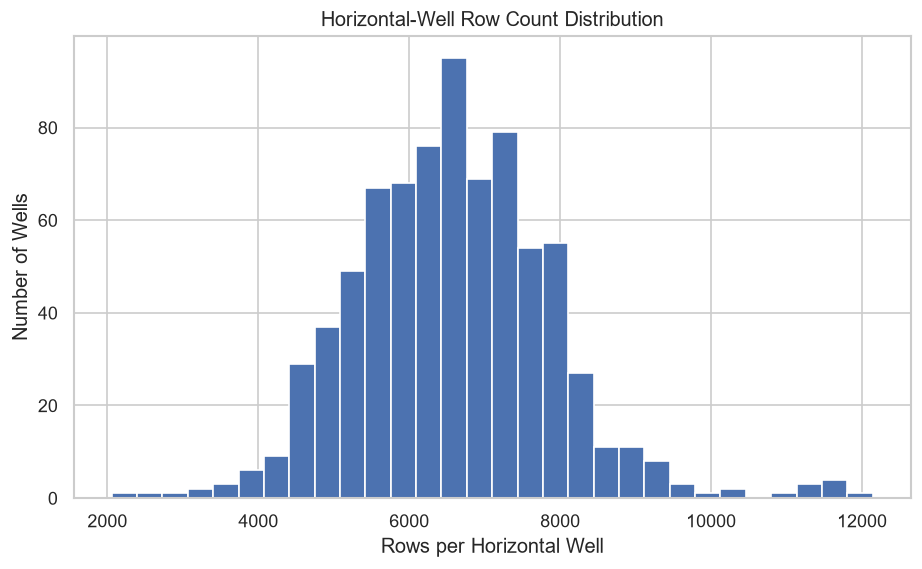

In [40]:
plt.figure(figsize=(9, 5))

well_summary["Horizontal_Rows"].plot(
    kind="hist",
    bins=30
)

plt.title("Horizontal-Well Row Count Distribution")
plt.xlabel("Rows per Horizontal Well")
plt.ylabel("Number of Wells")
plt.show()

**Interpretation.** The histogram shows heterogeneity in horizontal-well length.
The important finding is the wide spread around the median row count. This matters
because models trained without well-grouped validation may overfit length-related
structure. The limitation is that row count alone does not capture prediction
difficulty. The implication is that validation should group by well.


### 10. Prediction-Zone Distribution

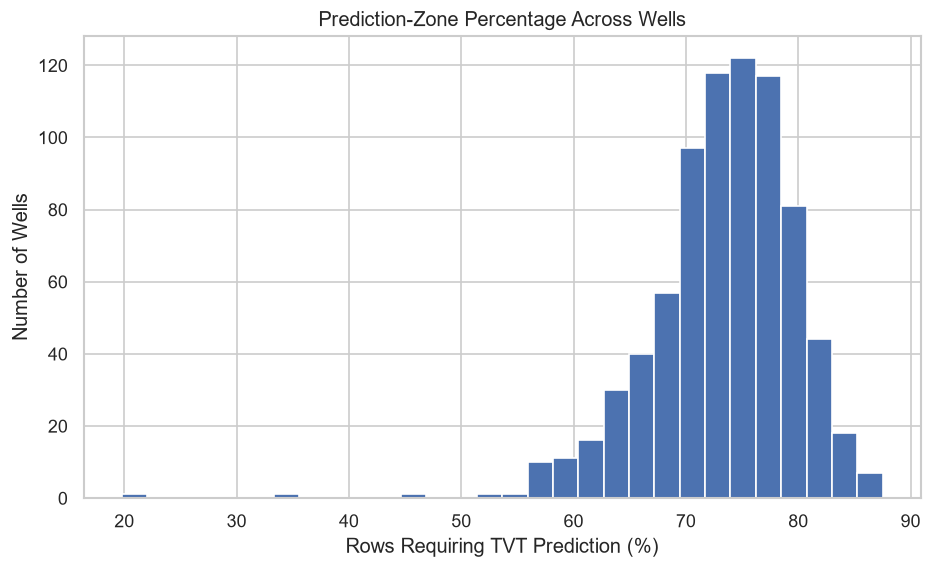

In [41]:
plt.figure(figsize=(9, 5))

well_summary["Prediction_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("Prediction-Zone Percentage Across Wells")
plt.xlabel("Rows Requiring TVT Prediction (%)")
plt.ylabel("Number of Wells")
plt.show()

**Interpretation.** Prediction-zone percentage is typically high across wells.
The results indicate that most wells leave a large trailing region without
`TVT_input`. This should guide horizon-aware baselines and features. Evidence is
training-only; test horizons are compared later.


### 11. GR Missingness Distribution

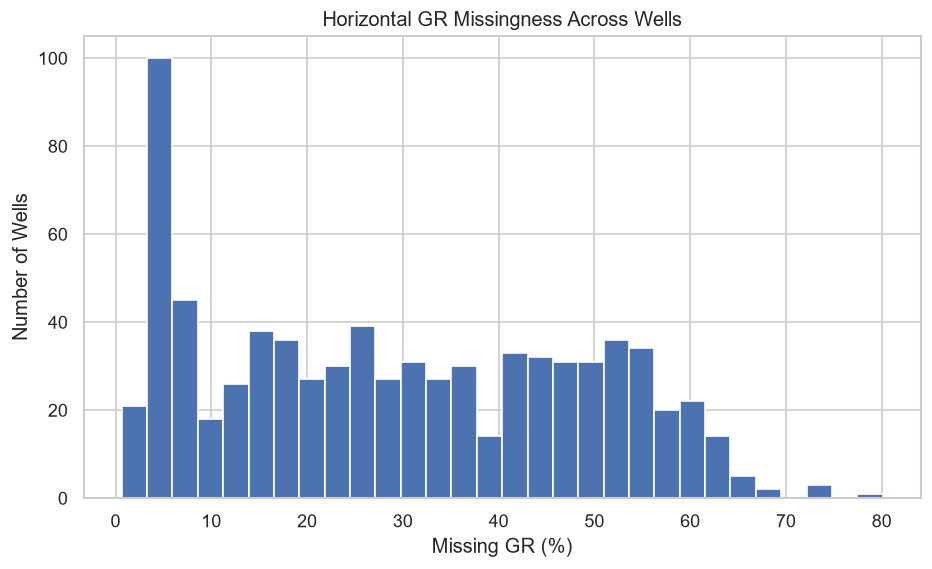

In [42]:
plt.figure(figsize=(9, 5))

well_summary["GR_Missing_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("Horizontal GR Missingness Across Wells")
plt.xlabel("Missing GR (%)")
plt.ylabel("Number of Wells")
plt.show()

**Interpretation.** Ordinary GR missingness varies substantially among wells.
The pattern suggests GR usefulness will be uneven. Missing GR should not be
silently filled without validation. This is separate from intentional
`TVT_input` missingness.


### 12. GR Missingness in the Prediction Section

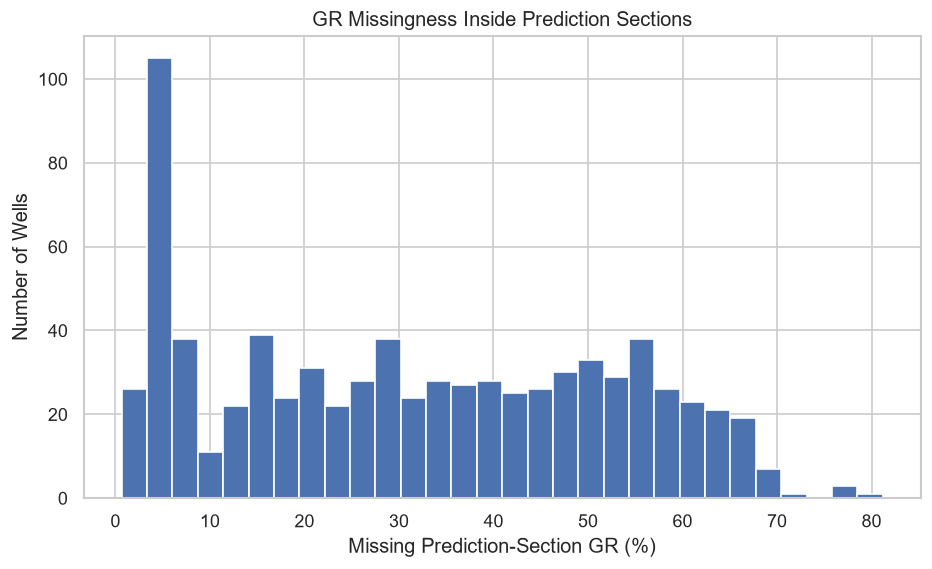

In [43]:
plt.figure(figsize=(9, 5))

well_summary["Prediction_GR_Missing_Percentage"].plot(
    kind="hist",
    bins=30
)

plt.title("GR Missingness Inside Prediction Sections")
plt.xlabel("Missing Prediction-Section GR (%)")
plt.ylabel("Number of Wells")
plt.show()

### 13. Prediction Length vs GR Missingness

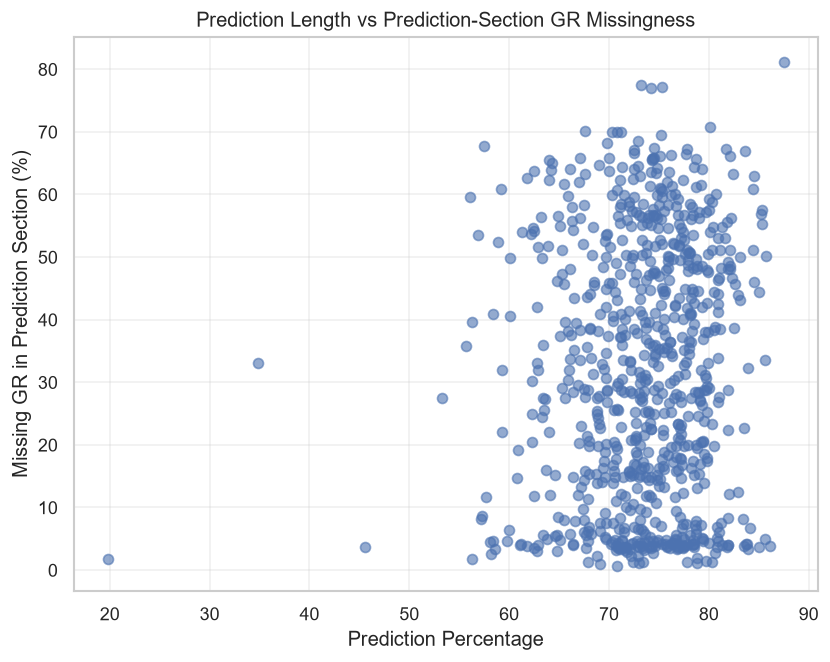

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    well_summary["Prediction_Percentage"],
    well_summary["Prediction_GR_Missing_Percentage"],
    alpha=0.6
)

plt.title("Prediction Length vs Prediction-Section GR Missingness")
plt.xlabel("Prediction Percentage")
plt.ylabel("Missing GR in Prediction Section (%)")
plt.grid(alpha=0.3)
plt.show()

### 14. TVT–Z Correlation Across Wells

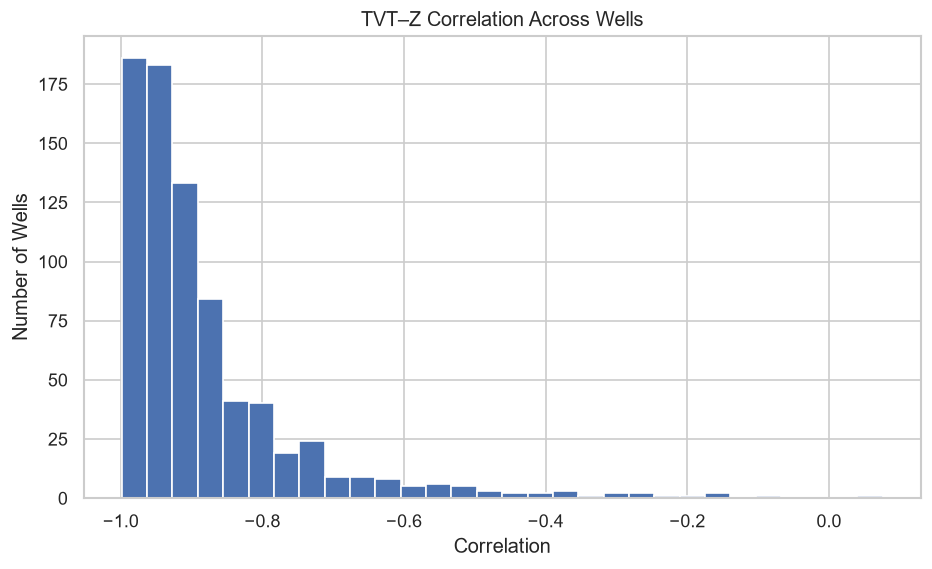

In [45]:
plt.figure(figsize=(9, 5))

well_summary["Z_TVT_Correlation"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("TVT–Z Correlation Across Wells")
plt.xlabel("Correlation")
plt.ylabel("Number of Wells")
plt.show()

### 15. GR–TVT Correlation Across Wells

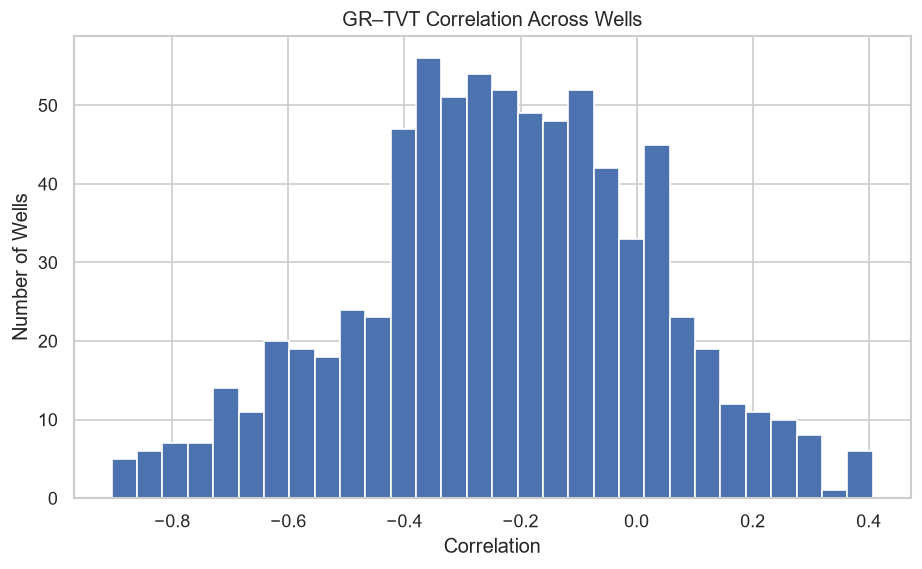

In [46]:
plt.figure(figsize=(9, 5))

well_summary["GR_TVT_Correlation"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("GR–TVT Correlation Across Wells")
plt.xlabel("Correlation")
plt.ylabel("Number of Wells")
plt.show()

### 16. Recent TVT Slope Distribution

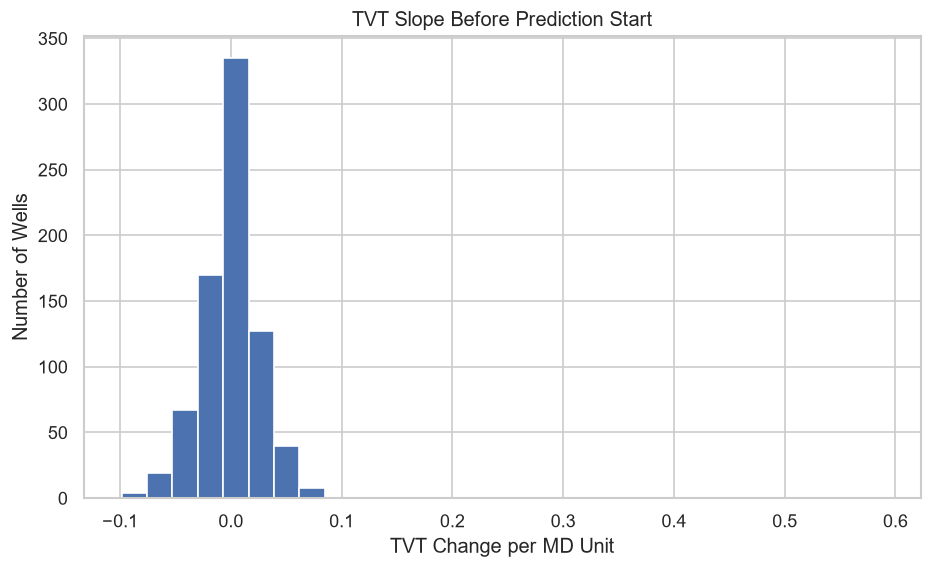

In [47]:
plt.figure(figsize=(9, 5))

well_summary["Prefix_Slope_Last_100"].dropna().plot(
    kind="hist",
    bins=30
)

plt.title("TVT Slope Before Prediction Start")
plt.xlabel("TVT Change per MD Unit")
plt.ylabel("Number of Wells")
plt.show()

### 17. Inspect Difficult Wells

#### Longest prediction sections

In [48]:
display(
    well_summary
    .nlargest(10, "Prediction_Percentage")
    [
        [
            "Well_ID",
            "Horizontal_Rows",
            "Known_Rows",
            "Prediction_Rows",
            "Prediction_Percentage",
            "Prediction_GR_Missing_Percentage"
        ]
    ]
)

,Well_ID,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_GR_Missing_Percentage
383,86454a6f,9100,1136,7964,87.5165,81.1778
318,6e9ccd38,9619,1337,8282,86.1004,3.8879
305,684a6fc1,11449,1631,9818,85.7542,50.2241
211,46d41ff6,9226,1325,7901,85.6384,33.5021
104,25050f63,7155,1031,6124,85.5905,4.9967
435,96ae5806,11527,1688,9839,85.3561,55.2394
521,ae0784a8,9171,1348,7823,85.3015,57.4716
696,ea3a0e38,11794,1742,10052,85.2298,56.9140
136,2d9f6cb9,8627,1289,7338,85.0585,3.6250
157,35b30c7f,11270,1691,9579,84.9956,44.3888


#### Highest prediction-section GR missingness

In [49]:
display(
    well_summary
    .nlargest(10, "Prediction_GR_Missing_Percentage")
    [
        [
            "Well_ID",
            "Prediction_Percentage",
            "GR_Missing_Percentage",
            "Prediction_GR_Missing_Percentage",
            "Longest_GR_Missing_Run"
        ]
    ]
)

,Well_ID,Prediction_Percentage,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run
383,86454a6f,87.5165,80.0989,81.1778,27
127,2be5c96a,73.1792,72.9706,77.4347,20
241,512943b2,75.2732,72.8484,77.1326,25
577,c36625df,74.2562,74.6946,76.9296,25
326,7224331b,80.1348,68.9796,70.8560,28
524,aed44918,67.6368,65.7463,70.0625,16
590,c70c0e01,71.1904,68.3837,70.0371,20
609,cd7f1687,70.7574,63.7352,70.0142,22
293,62a6f539,70.3027,62.4405,69.9973,25
751,fa31da94,75.2432,63.7030,69.5047,19


#### Typewell does not fully cover horizontal TVT

In [50]:
display(
    well_summary.loc[
        ~well_summary["Typewell_Covers_Horizontal_TVT"],
        [
            "Well_ID",
            "Typewell_TVT_Min",
            "Typewell_TVT_Max",
            "Horizontal_TVT_Min",
            "Horizontal_TVT_Max"
        ]
    ]
)

,Well_ID,Typewell_TVT_Min,Typewell_TVT_Max,Horizontal_TVT_Min,Horizontal_TVT_Max
7,02e7fe5a,"11,782.6200","12,285.1000","11,356.1300","12,199.3900"
27,0bbf5e67,"10,167.9500","10,971.9500","10,180.1300","10,972.0600"
37,10b89021,"11,782.6200","12,285.1000","11,311.0800","12,161.1800"
130,2cee0cba,"10,451.4500","11,245.4500","10,463.6700","11,246.7400"
152,3417285d,"11,782.6200","12,285.1000","11,137.8500","12,210.6200"
182,3c3dbcbc,"11,168.9000","12,051.8400","11,051.2400","11,877.6500"
312,6ae68655,"11,782.6200","12,285.1000","11,387.9800","12,133.5900"
352,7993a768,"11,782.6200","12,285.1000","11,439.1700","12,172.3000"
555,bc4381e2,"11,782.6200","12,285.1000","11,207.2100","12,147.7600"
708,ecdab904,"11,782.6200","12,285.1000","11,232.9800","12,200.2300"


#### Invalid prediction boundaries

In [51]:
display(
    well_summary.loc[
        ~well_summary["Clean_Prediction_Boundary"]
    ]
)

,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Final_TVT,Delta_TVT_LastKnown_to_Final,Abs_Delta_TVT,Prediction_Horizon_MD,TVT_Change_Per_MD,Clean_Prediction_Boundary,Unexpected_Internal_Gaps,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,X_Min,X_Max,Y_Min,Y_Max,Z_Min,Z_Max,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Typewell_GR_Min,Typewell_GR_Max,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Pred_Region_TVT_Min,Pred_Region_TVT_Max,Coverage_Lower_Margin,Coverage_Upper_Margin,Pred_Coverage_Lower_Margin,Pred_Coverage_Upper_Margin,Typewell_Covers_Horizontal_TVT,Typewell_Covers_Prediction_TVT,Coverage_Category,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows


### 18. Dataset Scale Summary (Train vs Test)

This section reports corpus-level scale for training and test pairs. Test targets
are not used. Large counts use comma formatting.


In [52]:
(
    test_typewell_files,
    test_horizontal_files,
    test_typewell_map,
    test_horizontal_map,
    test_complete_ids,
    test_well_id_validation,
    test_malformed,
    test_unmatched,
) = build_well_maps(TEST_DIR)

test_summaries = []
for well_id in test_complete_ids:
    # Feature-side summary only: reuse loader but drop target-dependent claims later
    test_summaries.append(
        summarize_well(
            well_id,
            typewell_map_ref=test_typewell_map,
            horizontal_map_ref=test_horizontal_map,
        )
    )
test_summary = pd.DataFrame(test_summaries)

# For test wells, TVT may be absent or unavailable for scoring; keep feature stats
# and TVT_input-based prediction masks only for shift diagnostics.

train_horizontal_rows = int(well_summary["Horizontal_Rows"].sum())
train_typewell_rows = int(well_summary["Typewell_Rows"].sum())
test_horizontal_rows = int(test_summary["Horizontal_Rows"].sum()) if len(test_summary) else 0
test_typewell_rows = int(test_summary["Typewell_Rows"].sum()) if len(test_summary) else 0
train_pred_rows = int(well_summary["Prediction_Rows"].sum())

sample_horizontal = pd.read_csv(horizontal_map[complete_ids[0]])
sample_typewell = pd.read_csv(typewell_map[complete_ids[0]])
numeric_cols = sample_horizontal.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = sample_horizontal.select_dtypes(exclude=[np.number]).columns.tolist()

# Approximate overall missing counts from well-level rates
approx_gr_missing = int(
    round((well_summary["GR_Missing_Percentage"] / 100 * well_summary["Horizontal_Rows"]).sum())
)
approx_tvt_input_missing = train_pred_rows

dataset_scale_table = pd.DataFrame(
    [
        {"Metric": "Number of training well pairs", "Value": f"{len(well_summary):,}"},
        {"Metric": "Number of test well pairs", "Value": f"{len(test_complete_ids):,}"},
        {"Metric": "Total training horizontal rows", "Value": f"{train_horizontal_rows:,}"},
        {"Metric": "Total training typewell rows", "Value": f"{train_typewell_rows:,}"},
        {"Metric": "Total test horizontal rows", "Value": f"{test_horizontal_rows:,}"},
        {"Metric": "Total test typewell rows", "Value": f"{test_typewell_rows:,}"},
        {
            "Metric": "Median / min / max rows per horizontal well (train)",
            "Value": (
                f"{int(well_summary['Horizontal_Rows'].median()):,} / "
                f"{int(well_summary['Horizontal_Rows'].min()):,} / "
                f"{int(well_summary['Horizontal_Rows'].max()):,}"
            ),
        },
        {
            "Metric": "Numeric / categorical columns (sample horizontal)",
            "Value": f"{len(numeric_cols)} / {len(categorical_cols)}",
        },
        {
            "Metric": "Approx. GR missing values (train horizontal)",
            "Value": f"{approx_gr_missing:,}",
        },
        {
            "Metric": "Prediction-region rows / percentage (train)",
            "Value": (
                f"{train_pred_rows:,} / "
                f"{100 * train_pred_rows / train_horizontal_rows:.2f}%"
            ),
        },
    ]
)

display(dataset_scale_table)
dataset_scale_table.to_csv(TABLES_DIR / "dataset_scale_summary.csv", index=False)
display(test_well_id_validation)


,Metric,Value
0,Number of training well pairs,773
1,Number of test well pairs,3
2,Total training horizontal rows,"5,092,255"
3,Total training typewell rows,"1,567,045"
4,Total test horizontal rows,"19,221"
5,Total test typewell rows,"5,798"
6,Median / min / max rows per horizontal well (t...,"6,576 / 2,058 / 12,141"
7,Numeric / categorical columns (sample horizontal),13 / 0
8,Approx. GR missing values (train horizontal),"1,507,972"
9,Prediction-region rows / percentage (train),"3,783,989 / 74.31%"


,Metric,Count
0,Number of horizontal wells,3
1,Number of typewells,3
2,Number of matched pairs,3
3,Number of unmatched files,0
4,Number of malformed IDs,0


**Interpretation.** The scale table shows hundreds of training pairs versus only
a few test pairs, and millions of training horizontal rows with a large
prediction-region share. This matters for computational cost and for any
train–test shift claims. The limitation is that missing-value totals for GR are
approximated from well-level rates. The implication is that modelling and
validation must be well-grouped and that test-shift conclusions remain provisional.


### 19. Per-Well `TVT_input` Region Diagnostics

For each training well, summarise known versus prediction regions defined by
`TVT_input`. This missingness is intentional and must not be handled with
conventional mean/median imputation. Correlation of `TVT_input` with `TVT` on
known rows is expected to be 1.0 by construction and is not treated as a
predictive discovery.


In [53]:
tvt_input_diagnostics = well_summary[
    [
        "Well_ID",
        "Horizontal_Rows",
        "Known_Rows",
        "Prediction_Rows",
        "Prediction_Percentage",
        "Prediction_Start_MD",
        "Last_Known_TVT",
        "Prediction_Horizon_MD",
        "Clean_Prediction_Boundary",
        "Unexpected_Internal_Gaps",
        "TVT_Input_Matches_TVT",
    ]
].copy()

diag_summary = pd.DataFrame(
    {
        "Metric": [
            "Wells with clean trailing TVT_input block",
            "Wells with unexpected internal gaps",
            "Wells where known TVT_input matches TVT",
            "Median prediction-region percentage",
            "Median prediction-horizon MD",
            "Median known rows",
            "Median prediction rows",
        ],
        "Value": [
            int(tvt_input_diagnostics["Clean_Prediction_Boundary"].sum()),
            int(tvt_input_diagnostics["Unexpected_Internal_Gaps"].sum()),
            int(tvt_input_diagnostics["TVT_Input_Matches_TVT"].sum()),
            round(tvt_input_diagnostics["Prediction_Percentage"].median(), 2),
            round(tvt_input_diagnostics["Prediction_Horizon_MD"].median(), 2),
            int(tvt_input_diagnostics["Known_Rows"].median()),
            int(tvt_input_diagnostics["Prediction_Rows"].median()),
        ],
    }
)

display(diag_summary)
display(tvt_input_diagnostics.describe(include=[np.number]).T)
tvt_input_diagnostics.to_csv(TABLES_DIR / "tvt_input_region_diagnostics.csv", index=False)
diag_summary.to_csv(TABLES_DIR / "tvt_input_diagnostics_summary.csv", index=False)


,Metric,Value
0,Wells with clean trailing TVT_input block,773.0000
1,Wells with unexpected internal gaps,0.0000
2,Wells where known TVT_input matches TVT,773.0000
3,Median prediction-region percentage,74.0000
4,Median prediction-horizon MD,"4,839.0000"
5,Median known rows,"1,703.0000"
6,Median prediction rows,"4,840.0000"


,count,mean,std,min,25%,50%,75%,max
Horizontal_Rows,773.0000,"6,587.6520","1,311.4635","2,058.0000","5,706.0000","6,576.0000","7,388.0000","12,141.0000"
Known_Rows,773.0000,"1,692.4528",217.3438,851.0000,"1,546.0000","1,703.0000","1,839.0000","2,392.0000"
Prediction_Rows,773.0000,"4,895.1992","1,301.1784",407.0000,"4,044.0000","4,840.0000","5,694.0000","10,052.0000"
Prediction_Percentage,773.0000,73.3161,6.3776,19.7765,70.0344,73.9991,77.5462,87.5165
Prediction_Start_MD,773.0000,"12,592.9211",652.0565,"10,943.0000","12,089.0000","12,409.0000","13,098.0000","14,132.0000"
Last_Known_TVT,773.0000,"11,551.0561",619.9044,"10,055.2600","11,031.3300","11,368.7100","12,055.5400","12,873.0700"
Prediction_Horizon_MD,773.0000,"4,894.1992","1,301.1784",406.0000,"4,043.0000","4,839.0000","5,693.0000","10,051.0000"


**Interpretation.** Across training wells, `TVT_input` almost always forms a
clean trailing missing block and matches `TVT` on known rows. The median
prediction share is large. These results indicate that `TVT_input` is a
structured mask, not accidental missingness. Conventional imputation would be
inappropriate. Later feature engineering should preserve the known/prediction
boundary explicitly.


### 20. Criteria-Based Selection of Three Example Wells

Selection is reproducible and automatic:

1. **Typical well:** minimise absolute deviation from dataset medians of
   horizontal row count, prediction-region percentage and GR missingness.
2. **Long-horizon well:** maximise `Prediction_Horizon_MD` (upper end).
3. **Data-quality challenge:** maximise a composite of GR missingness,
   longest GR missing run and incomplete typewell coverage.


In [54]:
median_rows = well_summary["Horizontal_Rows"].median()
median_pred_pct = well_summary["Prediction_Percentage"].median()
median_gr_miss = well_summary["GR_Missing_Percentage"].median()

typical_scores = (
    ((well_summary["Horizontal_Rows"] - median_rows).abs() / median_rows)
    + ((well_summary["Prediction_Percentage"] - median_pred_pct).abs() / median_pred_pct)
    + ((well_summary["GR_Missing_Percentage"] - median_gr_miss).abs() / max(median_gr_miss, 1e-6))
)
typical_well_id = well_summary.loc[typical_scores.idxmin(), "Well_ID"]

long_horizon_well_id = well_summary.loc[
    well_summary["Prediction_Horizon_MD"].idxmax(),
    "Well_ID",
]

dq_score = (
    well_summary["GR_Missing_Percentage"].rank(pct=True)
    + well_summary["Longest_GR_Missing_Run"].rank(pct=True)
    + (~well_summary["Typewell_Covers_Horizontal_TVT"]).astype(float)
)
# Avoid duplicating already selected wells when possible
dq_candidates = well_summary.loc[
    ~well_summary["Well_ID"].isin([typical_well_id, long_horizon_well_id])
].copy()
dq_score_filtered = dq_score.loc[dq_candidates.index]
dq_well_id = well_summary.loc[dq_score_filtered.idxmax(), "Well_ID"]

selected_wells = pd.DataFrame(
    [
        {
            "Role": "Typical",
            "Well_ID": typical_well_id,
            "Criterion": "Closest to medians of rows, prediction %, GR missingness",
        },
        {
            "Role": "Long-horizon",
            "Well_ID": long_horizon_well_id,
            "Criterion": "Maximum Prediction_Horizon_MD",
        },
        {
            "Role": "Data-quality challenge",
            "Well_ID": dq_well_id,
            "Criterion": "High GR missingness / long missing runs / coverage issues",
        },
    ]
)

selected_detail = selected_wells.merge(well_summary, on="Well_ID", how="left")
display(selected_detail[
    [
        "Role",
        "Well_ID",
        "Criterion",
        "Horizontal_Rows",
        "Prediction_Percentage",
        "Prediction_Horizon_MD",
        "GR_Missing_Percentage",
        "Longest_GR_Missing_Run",
        "Typewell_Covers_Horizontal_TVT",
        "Coverage_Category",
    ]
])
selected_wells.to_csv(TABLES_DIR / "selected_example_wells.csv", index=False)
print("Selected well IDs:", selected_wells["Well_ID"].tolist())


,Role,Well_ID,Criterion,Horizontal_Rows,Prediction_Percentage,Prediction_Horizon_MD,GR_Missing_Percentage,Longest_GR_Missing_Run,Typewell_Covers_Horizontal_TVT,Coverage_Category
0,Typical,3df4b19e,"Closest to medians of rows, prediction %, GR m...",6658,74.9174,"4,987.0000",28.0565,9,True,complete
1,Long-horizon,ea3a0e38,Maximum Prediction_Horizon_MD,11794,85.2298,"10,051.0000",54.1801,19,True,complete
2,Data-quality challenge,10b89021,High GR missingness / long missing runs / cove...,7166,75.5512,"5,413.0000",50.6001,48,False,complete


Selected well IDs: ['3df4b19e', 'ea3a0e38', '10b89021']


**Interpretation.** The three well IDs above are produced by explicit numeric
criteria rather than manual cherry-picking. They provide complementary views of
typical behaviour, long prediction horizons and data-quality stress cases for
the multi-panel profiles that follow.


### 21. Multi-Panel Profiles for Selected Wells

Each selected well is plotted with MD against TVT, `TVT_input`, GR and Z,
prediction-start boundary, known/prediction colouring, missing GR intervals and
typewell TVT coverage where available.


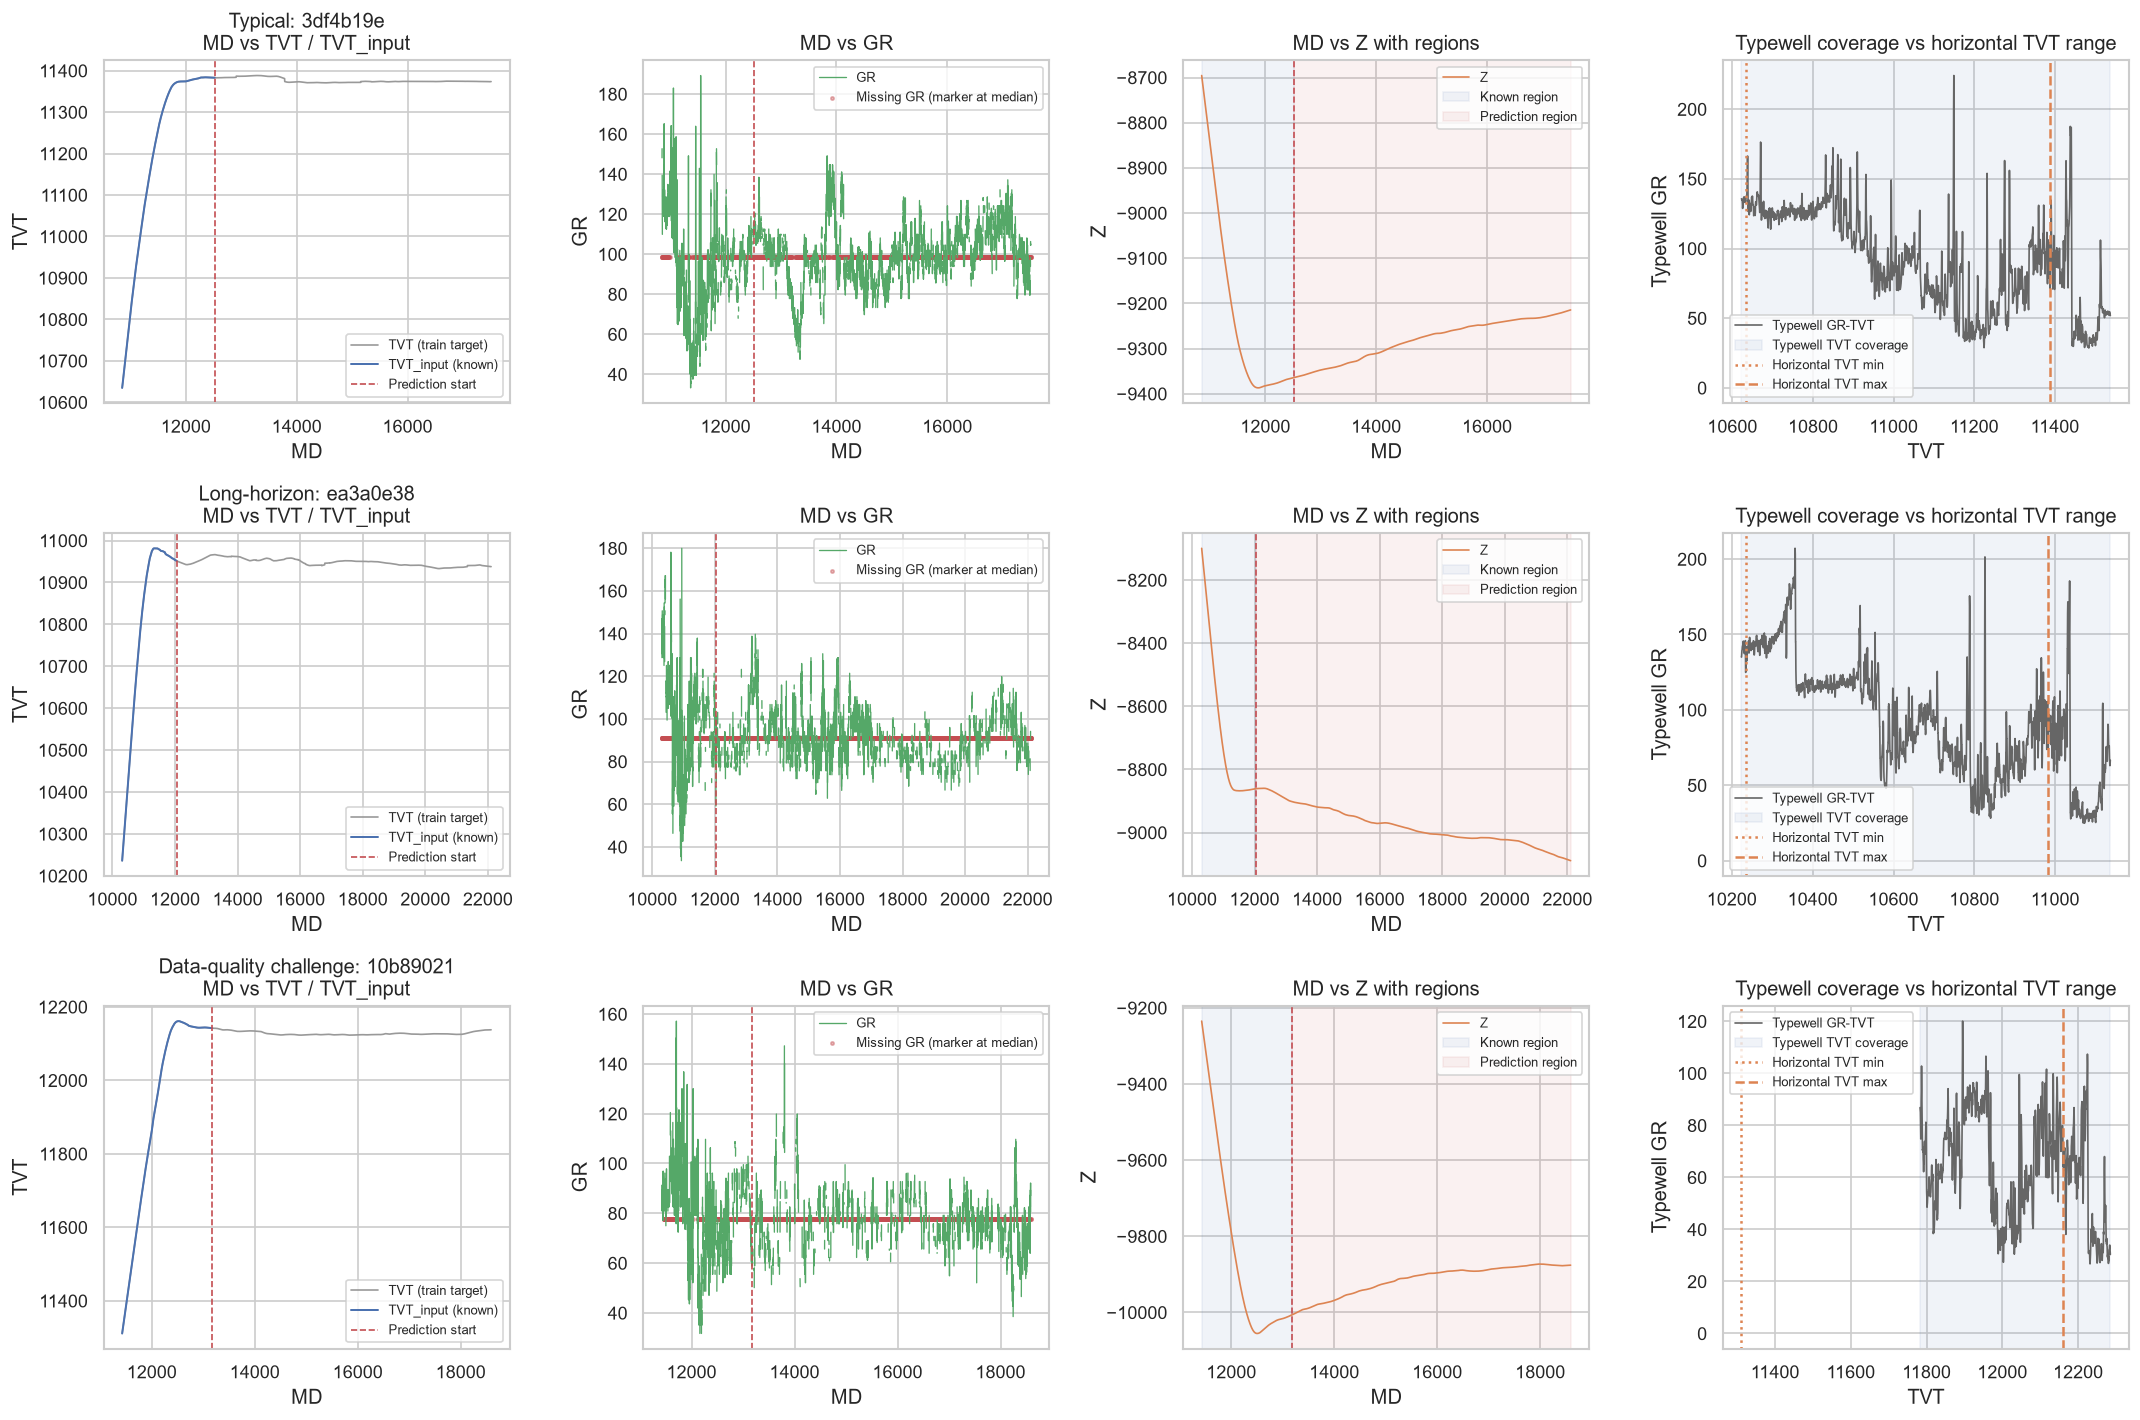

In [ ]:
def plot_well_profile(well_id, role, axes_row):
    horizontal = pd.read_csv(horizontal_map[well_id])
    typewell = pd.read_csv(typewell_map[well_id])
    known_mask = horizontal["TVT_input"].notna()
    pred_mask = ~known_mask
    pred_start_md = (
        float(horizontal.loc[pred_mask, "MD"].iloc[0]) if pred_mask.any() else np.nan
    )

    # TVT / TVT_input
    ax = axes_row[0]
    ax.plot(horizontal["MD"], horizontal["TVT"], color="0.6", lw=1, label="TVT (train target)")
    ax.plot(
        horizontal.loc[known_mask, "MD"],
        horizontal.loc[known_mask, "TVT_input"],
        color="C0",
        lw=1.2,
        label="TVT_input (known)",
    )
    if pd.notna(pred_start_md):
        ax.axvline(pred_start_md, color="C3", ls="--", lw=1, label="Prediction start")
    ax.set_title(f"{role}: {well_id}\nMD vs TVT / TVT_input")
    ax.set_xlabel("MD")
    ax.set_ylabel("TVT")
    ax.legend(loc="best", fontsize=8)

    # GR with missing intervals
    ax = axes_row[1]
    ax.plot(horizontal["MD"], horizontal["GR"], color="C2", lw=0.8, label="GR")
    missing_gr = horizontal["GR"].isna()
    if missing_gr.any():
        ax.scatter(
            horizontal.loc[missing_gr, "MD"],
            np.full(missing_gr.sum(), horizontal["GR"].median()),
            s=4,
            color="C3",
            alpha=0.4,
            label="Missing GR (marker at median)",
        )
    if pd.notna(pred_start_md):
        ax.axvline(pred_start_md, color="C3", ls="--", lw=1)
    ax.set_title("MD vs GR")
    ax.set_xlabel("MD")
    ax.set_ylabel("GR")
    ax.legend(loc="best", fontsize=8)

    # Z
    ax = axes_row[2]
    ax.plot(horizontal["MD"], horizontal["Z"], color="C1", lw=1, label="Z")
    if pd.notna(pred_start_md):
        ax.axvline(pred_start_md, color="C3", ls="--", lw=1)
    ax.axvspan(
        horizontal["MD"].min(),
        pred_start_md if pd.notna(pred_start_md) else horizontal["MD"].min(),
        color="C0",
        alpha=0.08,
        label="Known region",
    )
    if pd.notna(pred_start_md):
        ax.axvspan(
            pred_start_md,
            horizontal["MD"].max(),
            color="C3",
            alpha=0.08,
            label="Prediction region",
        )
    ax.set_title("MD vs Z with regions")
    ax.set_xlabel("MD")
    ax.set_ylabel("Z")
    ax.legend(loc="best", fontsize=8)

    # Typewell coverage on TVT axis
    ax = axes_row[3]
    ax.plot(typewell["TVT"], typewell["GR"], color="0.4", lw=1, label="Typewell GR-TVT")
    ax.axvspan(
        typewell["TVT"].min(),
        typewell["TVT"].max(),
        color="C0",
        alpha=0.08,
        label="Typewell TVT coverage",
    )
    hmin, hmax = horizontal["TVT"].min(), horizontal["TVT"].max()
    ax.axhline(0, alpha=0)  # keep autoscaling stable
    ax.axvline(hmin, color="C1", ls=":", label="Horizontal TVT min")
    ax.axvline(hmax, color="C1", ls="--", label="Horizontal TVT max")
    ax.set_title("Typewell coverage vs horizontal TVT range")
    ax.set_xlabel("TVT")
    ax.set_ylabel("Typewell GR")
    ax.legend(loc="best", fontsize=8)


fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for row_idx, (_, row) in enumerate(selected_wells.iterrows()):
    plot_well_profile(row["Well_ID"], row["Role"], axes[row_idx])
plt.tight_layout()
fig.savefig(FIGURES_DIR / "selected_wells_multipanel.png", bbox_inches="tight")
plt.show()


**Interpretation.** The multi-panel profiles contrast a near-median well, a
long-horizon well and a data-quality challenge well. The important visual
finding is that prediction regions are trailing blocks with varying GR
availability and typewell overlap. This matters for baseline difficulty and
matching features. The limitation is that three wells cannot represent all
773 pairs. The implication is that model validation should include these
stress cases explicitly.


### 22. Feature Correlation Analysis (Pearson; Spearman supplement)

Build correlation heatmaps on a reproducible sample of training horizontal rows.
`TVT_input` is excluded. Correlation does not imply causation; Pearson captures
linear associations only and is not used alone for feature selection.


Correlation sample: 80,000 rows from 42 wells (seed=42). TVT_input excluded.


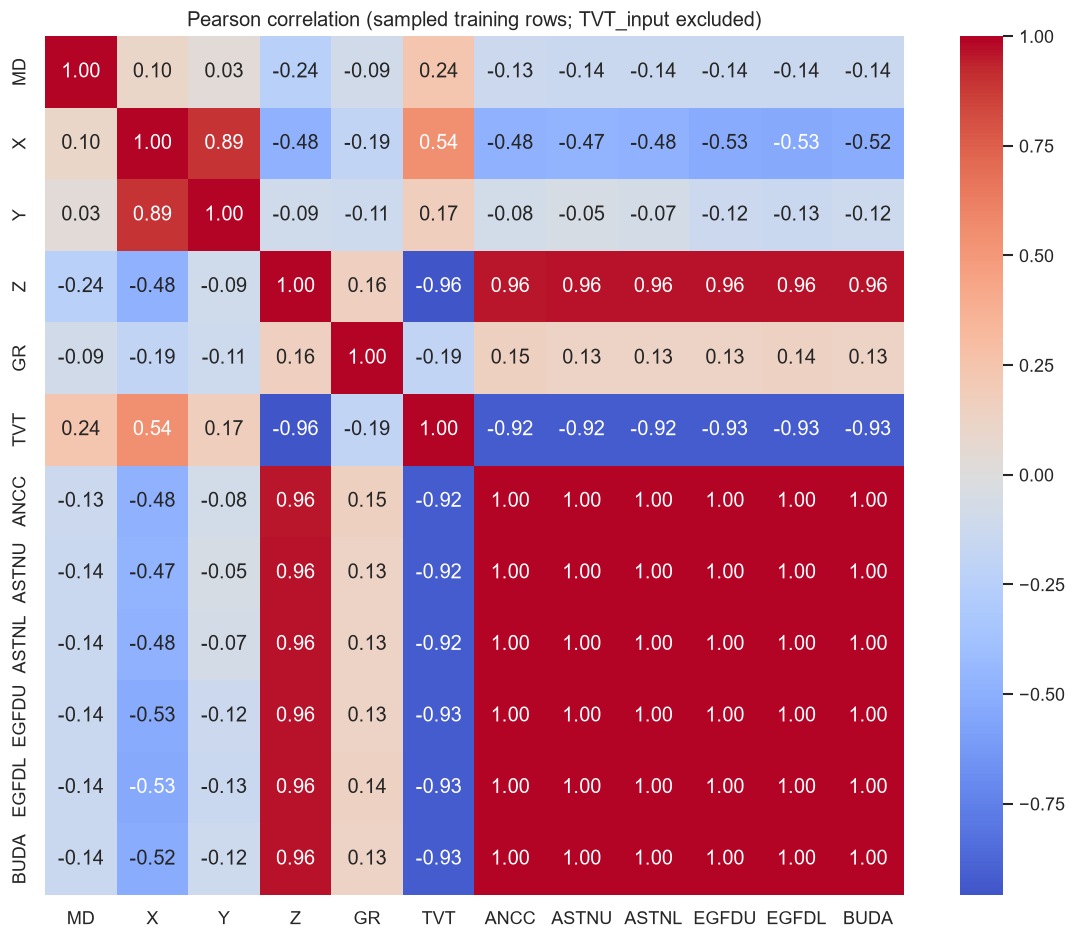

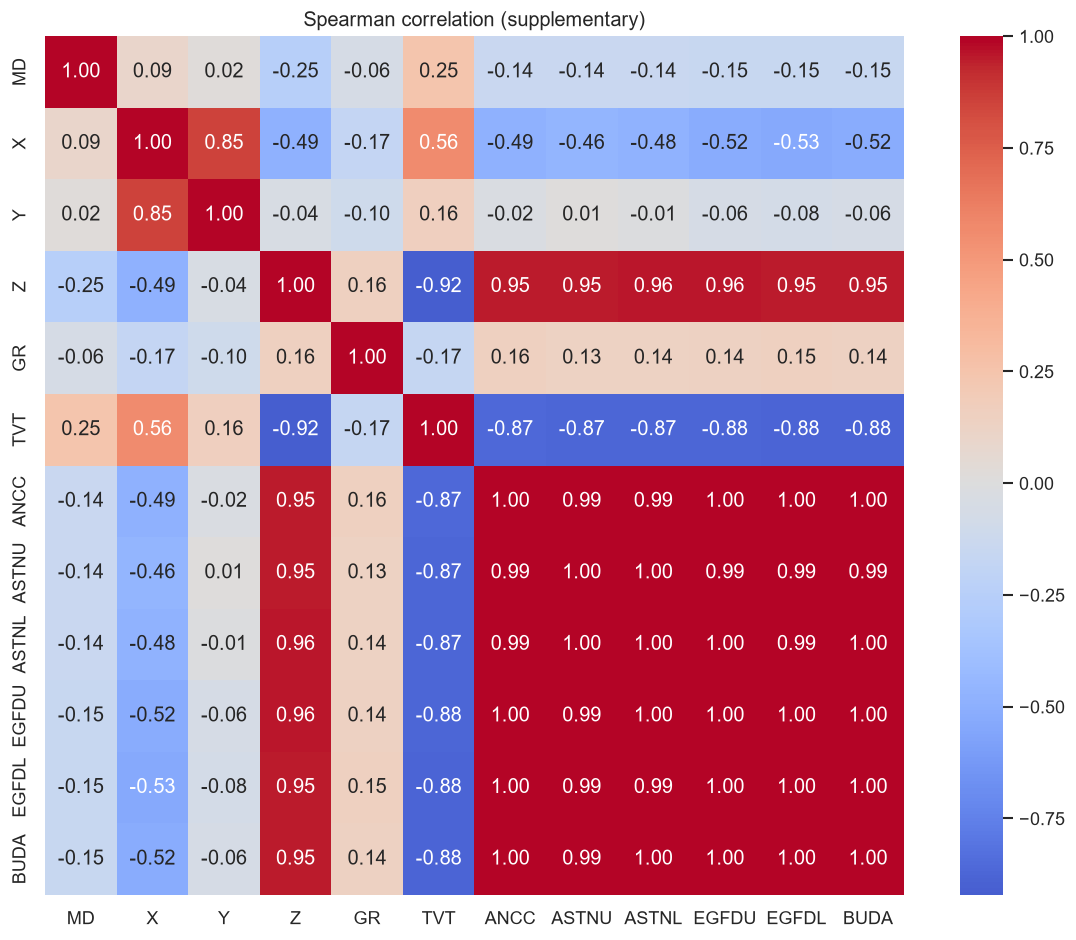

Absolute Pearson |corr| with TVT:


,abs_pearson_with_TVT
Z,0.9580
BUDA,0.9270
EGFDL,0.9260
EGFDU,0.9260
ASTNU,0.9240
ASTNL,0.9230
ANCC,0.9210
X,0.5450
MD,0.2410
GR,0.1930


Strong feature-feature correlations (possible redundancy):


,Feature_A,Feature_B,Abs_Pearson
129,EGFDL,EGFDU,0.9999
141,BUDA,EGFDU,0.9998
142,BUDA,EGFDL,0.9998
103,ASTNL,ASTNU,0.9995
83,ANCC,BUDA,0.9988
81,ANCC,EGFDU,0.9988
107,ASTNL,BUDA,0.9985
82,ANCC,EGFDL,0.9985
105,ASTNL,EGFDU,0.9982
80,ANCC,ASTNL,0.9976


In [56]:
corr_columns = [
    "MD", "X", "Y", "Z", "GR", "TVT",
    "ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA",
]

sample_wells = (
    well_summary["Well_ID"]
    .sample(n=min(40, len(well_summary)), random_state=RANDOM_SEED)
    .tolist()
)
# Always include the three selected wells
for well_id in selected_wells["Well_ID"]:
    if well_id not in sample_wells:
        sample_wells.append(well_id)

corr_frames = []
for well_id in sample_wells:
    df = pd.read_csv(horizontal_map[well_id])
    use_cols = [c for c in corr_columns if c in df.columns]
    corr_frames.append(df[use_cols])

corr_data = pd.concat(corr_frames, ignore_index=True)
max_rows = 80_000
if len(corr_data) > max_rows:
    corr_sample = corr_data.sample(n=max_rows, random_state=RANDOM_SEED)
else:
    corr_sample = corr_data

print(
    f"Correlation sample: {len(corr_sample):,} rows from {len(sample_wells)} wells "
    f"(seed={RANDOM_SEED}). TVT_input excluded."
)

pearson_corr = corr_sample.corr(method="pearson")
spearman_corr = corr_sample.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Pearson correlation (sampled training rows; TVT_input excluded)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pearson_correlation_heatmap.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Spearman correlation (supplementary)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "spearman_correlation_heatmap.png", bbox_inches="tight")
plt.show()

pearson_corr.to_csv(TABLES_DIR / "pearson_correlation_matrix.csv")
spearman_corr.to_csv(TABLES_DIR / "spearman_correlation_matrix.csv")

tvt_abs = pearson_corr["TVT"].drop(labels=["TVT"]).abs().sort_values(ascending=False)
print("Absolute Pearson |corr| with TVT:")
display(tvt_abs.round(3).to_frame("abs_pearson_with_TVT"))

ff = pearson_corr.copy()
ff_values = ff.to_numpy(copy=True)
np.fill_diagonal(ff_values, np.nan)
ff = pd.DataFrame(ff_values, index=ff.index, columns=ff.columns)
strong_ff = (
    ff.abs().stack().reset_index()
)
strong_ff.columns = ["Feature_A", "Feature_B", "Abs_Pearson"]
strong_ff = strong_ff.loc[strong_ff["Feature_A"] < strong_ff["Feature_B"]]
strong_ff = strong_ff.sort_values("Abs_Pearson", ascending=False).head(12)
print("Strong feature-feature correlations (possible redundancy):")
display(strong_ff)


**Interpretation.** The heatmaps summarise linear and rank associations among
available numeric features. Strong feature–feature correlations may indicate
redundancy (for example among formation tops or trajectory coordinates). Weak
linear association with TVT does not preclude nonlinear usefulness. Correlation
alone should not determine feature selection; grouped validation is required.


### 23. Train–Test Distribution Comparison

Compare available feature and structural distributions without using unavailable
test targets for modelling. With only a few test wells, any shift conclusion is
provisional.


,Metric,Train,Test
0,Number of well pairs,773,3
1,Total horizontal rows,5092255,19221
2,Median rows per horizontal well,"6,576.0000","6,384.0000"
3,Total typewell rows,1567045,5798
4,Median typewell rows,"1,874.0000","1,946.0000"
5,Median prediction-region %,73.9991,72.6790
6,Median GR missingness %,27.7038,12.4620
7,MD range (global min/max),9335.0–22964.0,10456.0–19136.0
8,X range,2855426.5–3039107.3,2967726.5–3010760.1
9,Y range,1007175.5–1141857.5,1060431.2–1089521.4


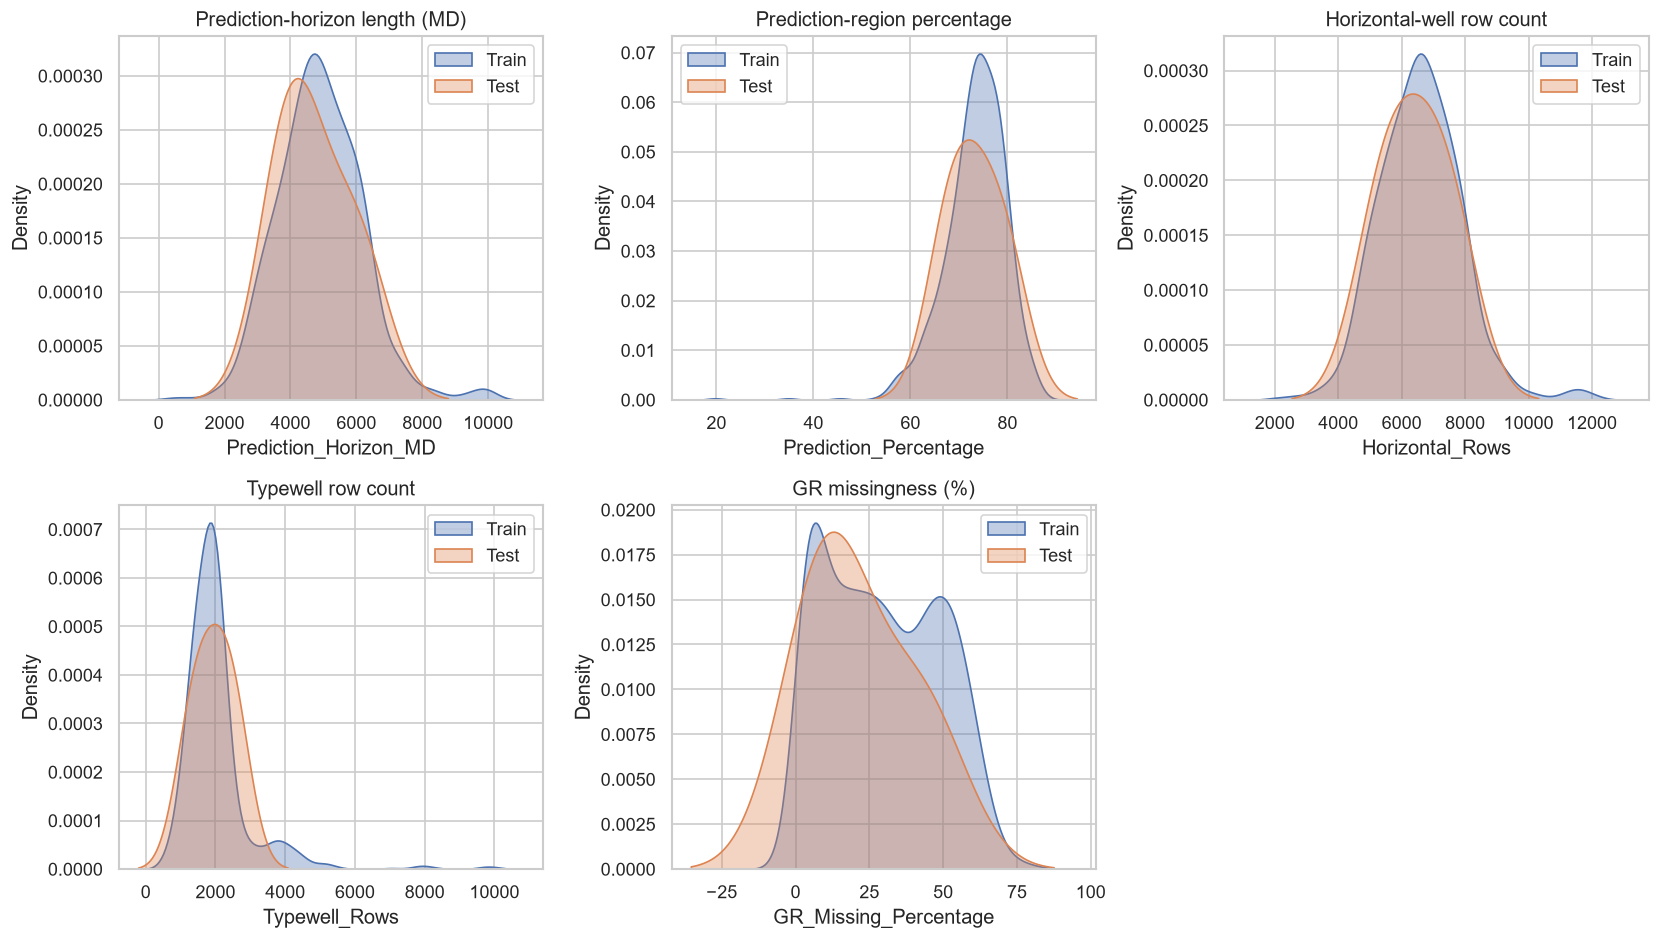

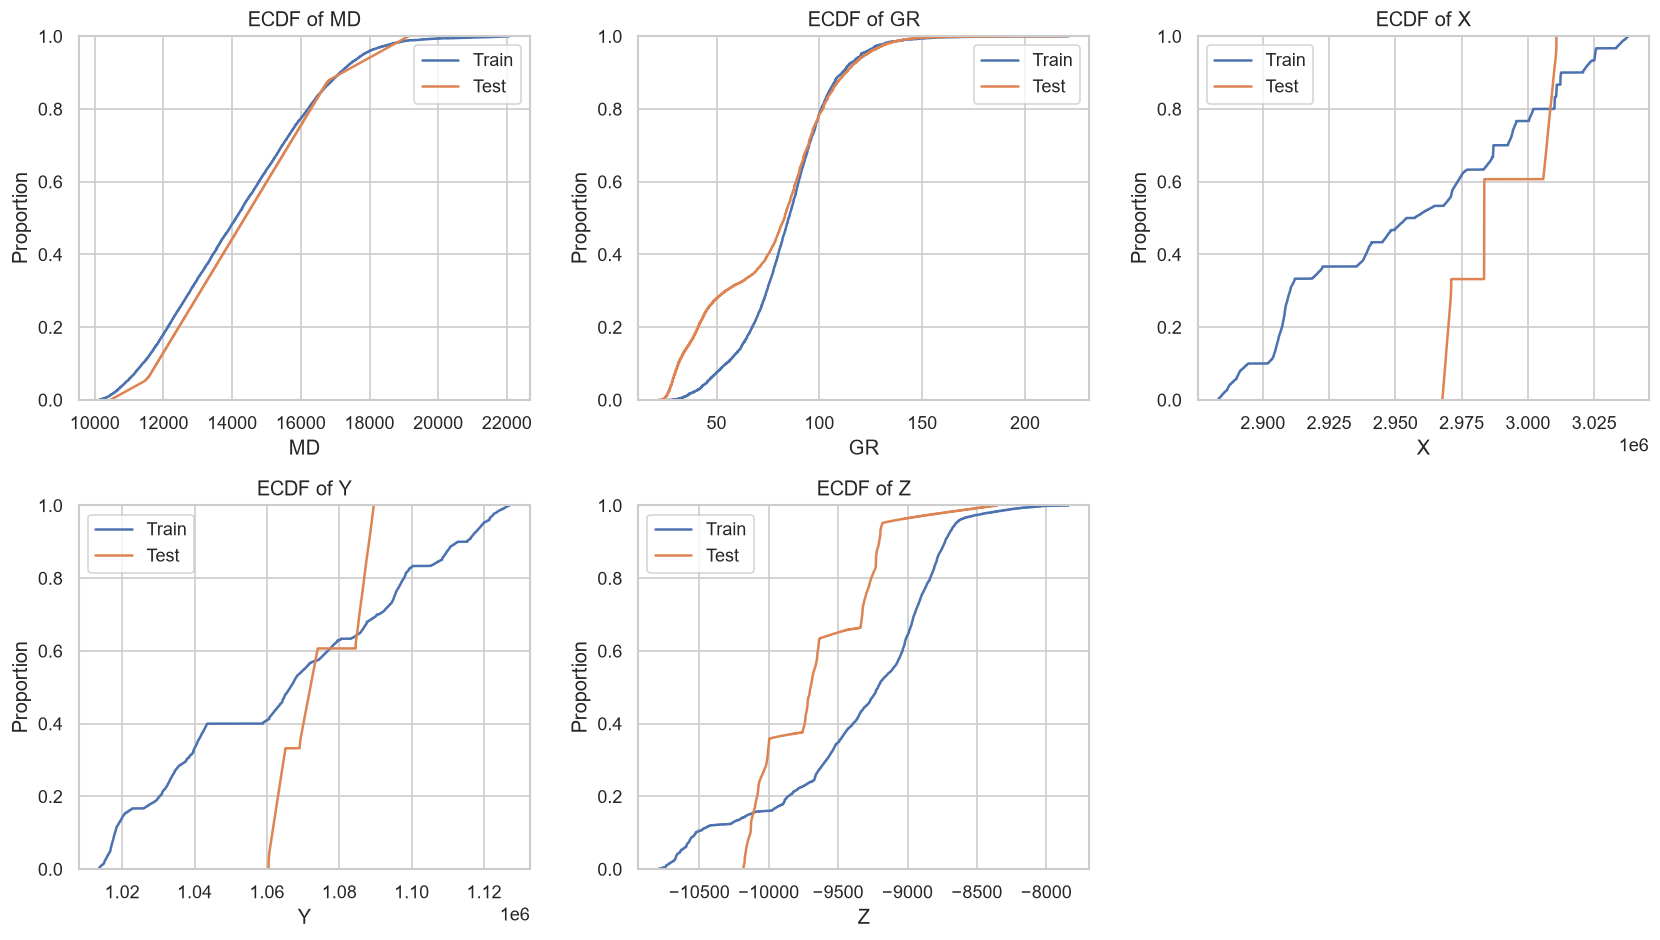

,Variable,KS_statistic,p_value,n_train,n_test
0,MD,0.0569,0.0000,15000,19221
1,GR,0.2057,0.0000,10510,15437
2,X,0.5333,0.0000,15000,19221
3,Y,0.4117,0.0000,15000,19221
4,Z,0.4310,0.0000,15000,19221


In [57]:
def split_comparison_table(train_df, test_df):
    rows = []
    rows.append(("Number of well pairs", len(train_df), len(test_df)))
    rows.append(("Total horizontal rows", int(train_df["Horizontal_Rows"].sum()), int(test_df["Horizontal_Rows"].sum())))
    rows.append(("Median rows per horizontal well", train_df["Horizontal_Rows"].median(), test_df["Horizontal_Rows"].median()))
    rows.append(("Total typewell rows", int(train_df["Typewell_Rows"].sum()), int(test_df["Typewell_Rows"].sum())))
    rows.append(("Median typewell rows", train_df["Typewell_Rows"].median(), test_df["Typewell_Rows"].median()))
    rows.append(("Median prediction-region %", train_df["Prediction_Percentage"].median(), test_df["Prediction_Percentage"].median()))
    rows.append(("Median GR missingness %", train_df["GR_Missing_Percentage"].median(), test_df["GR_Missing_Percentage"].median()))
    rows.append(("MD range (global min/max)", f"{train_df['MD_Min'].min():.1f}–{train_df['MD_Max'].max():.1f}", f"{test_df['MD_Min'].min():.1f}–{test_df['MD_Max'].max():.1f}"))
    rows.append(("X range", f"{train_df['X_Min'].min():.1f}–{train_df['X_Max'].max():.1f}", f"{test_df['X_Min'].min():.1f}–{test_df['X_Max'].max():.1f}"))
    rows.append(("Y range", f"{train_df['Y_Min'].min():.1f}–{train_df['Y_Max'].max():.1f}", f"{test_df['Y_Min'].min():.1f}–{test_df['Y_Max'].max():.1f}"))
    rows.append(("Z range", f"{train_df['Z_Min'].min():.1f}–{train_df['Z_Max'].max():.1f}", f"{test_df['Z_Min'].min():.1f}–{test_df['Z_Max'].max():.1f}"))
    rows.append(("Typewell TVT range", f"{train_df['Typewell_TVT_Min'].min():.1f}–{train_df['Typewell_TVT_Max'].max():.1f}", f"{test_df['Typewell_TVT_Min'].min():.1f}–{test_df['Typewell_TVT_Max'].max():.1f}"))
    rows.append(("Typewell GR range", f"{train_df['Typewell_GR_Min'].min():.1f}–{train_df['Typewell_GR_Max'].max():.1f}", f"{test_df['Typewell_GR_Min'].min():.1f}–{test_df['Typewell_GR_Max'].max():.1f}"))
    train_cols = sorted(pd.read_csv(horizontal_map[complete_ids[0]], nrows=0).columns)
    test_cols = sorted(pd.read_csv(test_horizontal_map[test_complete_ids[0]], nrows=0).columns) if test_complete_ids else []
    rows.append(("Available horizontal columns", ", ".join(train_cols), ", ".join(test_cols)))
    return pd.DataFrame(rows, columns=["Metric", "Train", "Test"])

train_test_table = split_comparison_table(well_summary, test_summary)
display(train_test_table)
train_test_table.to_csv(TABLES_DIR / "train_test_comparison.csv", index=False)

compare_cols = [
    ("Prediction_Horizon_MD", "Prediction-horizon length (MD)"),
    ("Prediction_Percentage", "Prediction-region percentage"),
    ("Horizontal_Rows", "Horizontal-well row count"),
    ("Typewell_Rows", "Typewell row count"),
    ("GR_Missing_Percentage", "GR missingness (%)"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, (col, title) in zip(axes, compare_cols):
    sns.kdeplot(well_summary[col].dropna(), ax=ax, label="Train", fill=True, alpha=0.35)
    if len(test_summary):
        sns.kdeplot(test_summary[col].dropna(), ax=ax, label="Test", fill=True, alpha=0.35)
    ax.set_title(title)
    ax.legend()
axes[-1].axis("off")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "train_test_structural_distributions.png", bbox_inches="tight")
plt.show()

# Sampled row-level MD/GR/X/Y/Z comparison
row_sample_train = []
for well_id in well_summary["Well_ID"].sample(n=min(30, len(well_summary)), random_state=RANDOM_SEED):
    df = pd.read_csv(horizontal_map[well_id], usecols=lambda c: c in {"MD", "GR", "X", "Y", "Z"})
    row_sample_train.append(df.sample(n=min(500, len(df)), random_state=RANDOM_SEED))
train_rows = pd.concat(row_sample_train, ignore_index=True)
train_rows["Split"] = "Train"

row_sample_test = []
for well_id in test_complete_ids:
    usecols = lambda c: c in {"MD", "GR", "X", "Y", "Z"}
    df = pd.read_csv(test_horizontal_map[well_id], usecols=usecols)
    row_sample_test.append(df)
test_rows = pd.concat(row_sample_test, ignore_index=True) if row_sample_test else pd.DataFrame()
if len(test_rows):
    test_rows["Split"] = "Test"

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, ["MD", "GR", "X", "Y", "Z"]):
    if col in train_rows:
        sns.ecdfplot(data=train_rows, x=col, ax=ax, label="Train")
    if len(test_rows) and col in test_rows:
        sns.ecdfplot(data=test_rows, x=col, ax=ax, label="Test")
    ax.set_title(f"ECDF of {col}")
    ax.legend()
axes[-1].axis("off")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "train_test_feature_ecdfs.png", bbox_inches="tight")
plt.show()

ks_rows = []
for col in ["MD", "GR", "X", "Y", "Z"]:
    a = train_rows[col].dropna()
    b = test_rows[col].dropna() if len(test_rows) and col in test_rows else pd.Series(dtype=float)
    if len(a) > 0 and len(b) > 0:
        stat, pval = stats.ks_2samp(a, b)
        ks_rows.append({"Variable": col, "KS_statistic": stat, "p_value": pval, "n_train": len(a), "n_test": len(b)})
ks_table = pd.DataFrame(ks_rows)
display(ks_table)
ks_table.to_csv(TABLES_DIR / "train_test_ks_stats.csv", index=False)
print("Warning: with few test wells and large row counts, KS p-values are easily small and should not be overinterpreted.")


**Interpretation.** Structural and feature ECDFs provide a provisional view of
train–test similarity. Because only a few test wells exist, apparent shifts may
reflect well identity rather than a stable population change. KS statistics are
reported cautiously and should not alone drive preprocessing decisions.


### 24. Known vs Prediction Region Feature Comparison

Within training wells, compare feature distributions between known
(`TVT_input` available) and prediction (`TVT_input` missing) regions. Observed
differences may largely reflect that prediction regions occur later along MD
rather than a fully independent population.


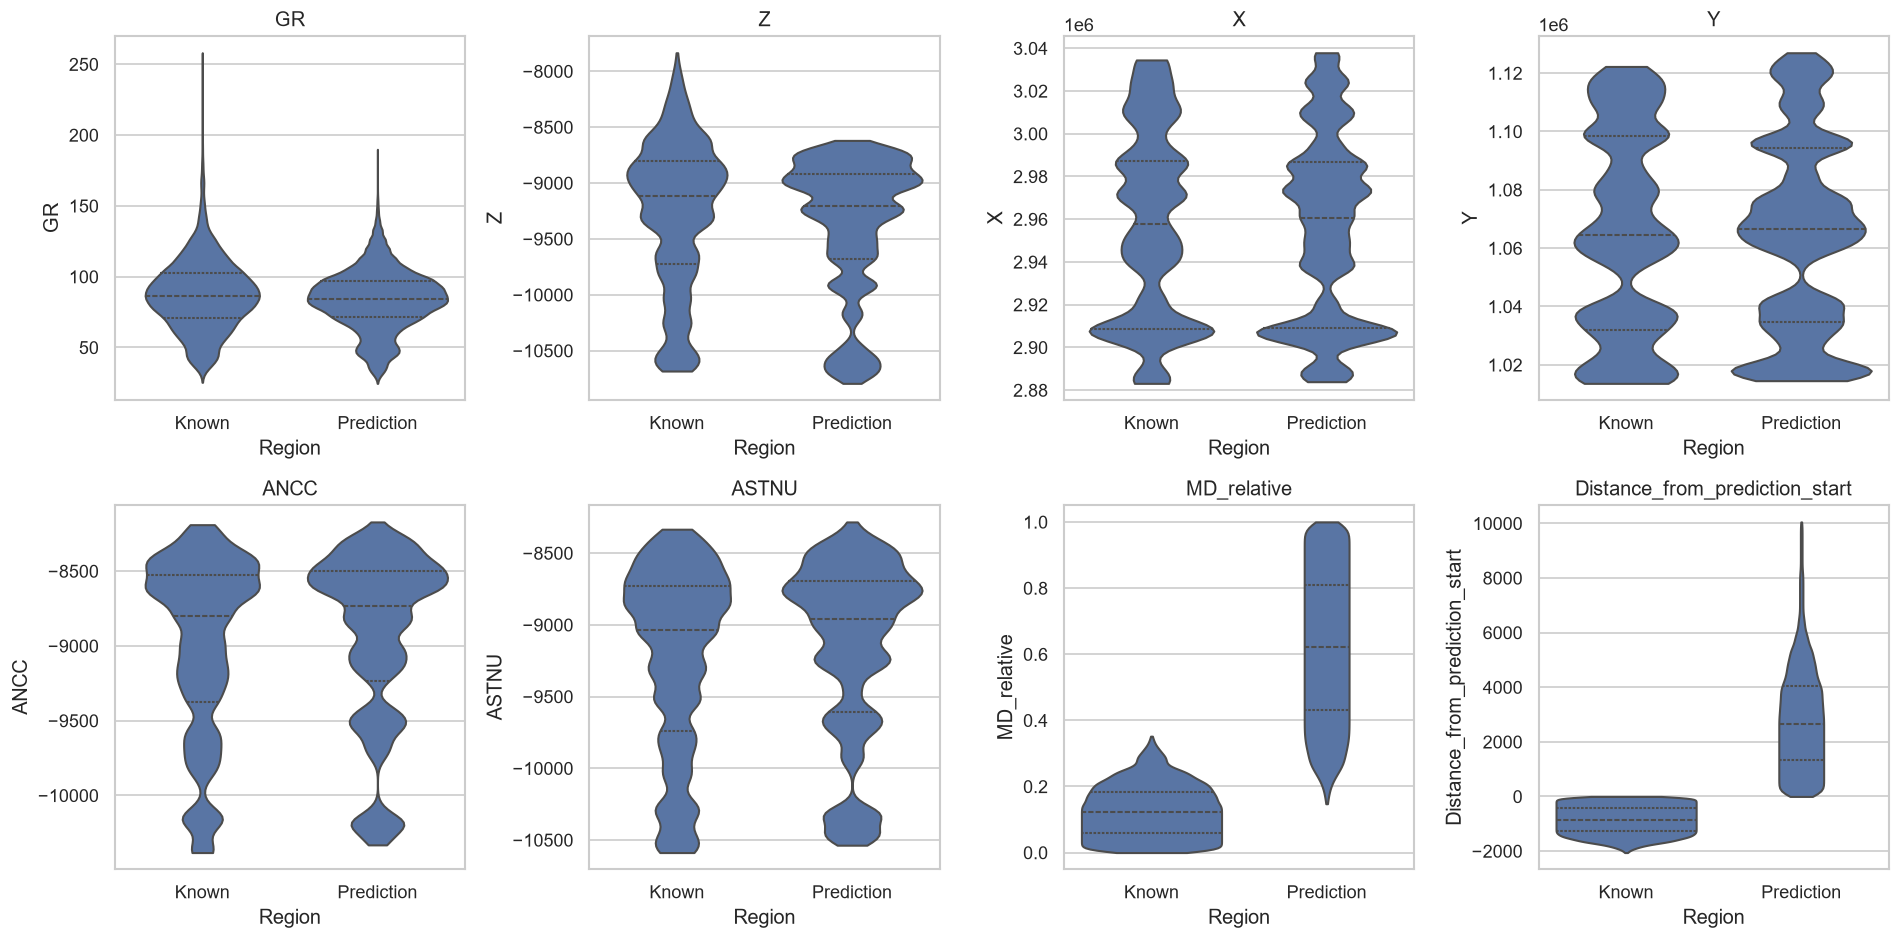

GR                   Z                          X  \
            median    mean      median        mean         median   
Region                                                              
Known      86.6190 87.1701 -9,117.7800 -9,278.2743 2,957,582.2900   
Prediction 84.5246 83.3772 -9,205.3200 -9,379.7716 2,960,445.0300   

                                       Y                       ANCC  \
                     mean         median           mean      median   
Region                                                                
Known      2,957,402.5728 1,064,479.3500 1,064,867.9540 -8,800.3200   
Prediction 2,955,451.4205 1,066,538.1100 1,064,574.5466 -8,733.8450   

                             ASTNU             MD_relative         \
                  mean      median        mean      median   mean   
Region                                                              
Known      -9,001.2985 -9,037.1400 -9,239.2248      0.1212 0.1261   
Prediction -8,939.3012 -8,962.7600 -9,162.5627      0.6212 0.6197   

           Distance_from_prediction_start             
                                   median       mean  
Region                                                
Known                           -851.0000  -858.7498  
Prediction                     2,657.0000 2,846.5492

In [58]:
region_sample_wells = selected_wells["Well_ID"].tolist()
extra = (
    well_summary["Well_ID"]
    .sample(n=min(25, len(well_summary)), random_state=RANDOM_SEED)
    .tolist()
)
for well_id in extra:
    if well_id not in region_sample_wells:
        region_sample_wells.append(well_id)

region_frames = []
for well_id in region_sample_wells:
    df = pd.read_csv(horizontal_map[well_id])
    known_mask = df["TVT_input"].notna()
    pred_start_md = df.loc[~known_mask, "MD"].iloc[0] if (~known_mask).any() else np.nan
    tmp = df.copy()
    tmp["Region"] = np.where(known_mask, "Known", "Prediction")
    tmp["Well_ID"] = well_id
    tmp["MD_relative"] = (tmp["MD"] - tmp["MD"].min()) / (tmp["MD"].max() - tmp["MD"].min() + 1e-9)
    tmp["Distance_from_prediction_start"] = tmp["MD"] - pred_start_md if pd.notna(pred_start_md) else np.nan
    region_frames.append(tmp)

region_data = pd.concat(region_frames, ignore_index=True)

plot_vars = [c for c in ["GR", "Z", "X", "Y", "ANCC", "ASTNU", "MD_relative", "Distance_from_prediction_start"] if c in region_data.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, plot_vars):
    sns.violinplot(data=region_data, x="Region", y=col, ax=ax, inner="quartile", cut=0)
    ax.set_title(col)
for ax in axes[len(plot_vars):]:
    ax.axis("off")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "known_vs_prediction_violins.png", bbox_inches="tight")
plt.show()

region_summary = (
    region_data.groupby("Region")[plot_vars]
    .agg(["median", "mean"])
)
display(region_summary)
region_summary.to_csv(TABLES_DIR / "known_vs_prediction_summary.csv")


**Interpretation.** Feature distributions differ between known and prediction
regions for several variables. Because prediction regions generally occur later
in MD, these differences may reflect depth/progress effects rather than a
separate generative process. Feature engineering should consider relative MD and
distance from prediction start, and validation should avoid treating rows as IID.


### 25. Multi-Well Missingness Along Normalised Progress

A missingness heatmap over normalised well progress for the three selected wells
plus a reproducible additional sample. Wells are ordered by prediction-region
percentage. This distinguishes systematic trailing `TVT_input` gaps from
irregular GR gaps without plotting all 773 wells at once.


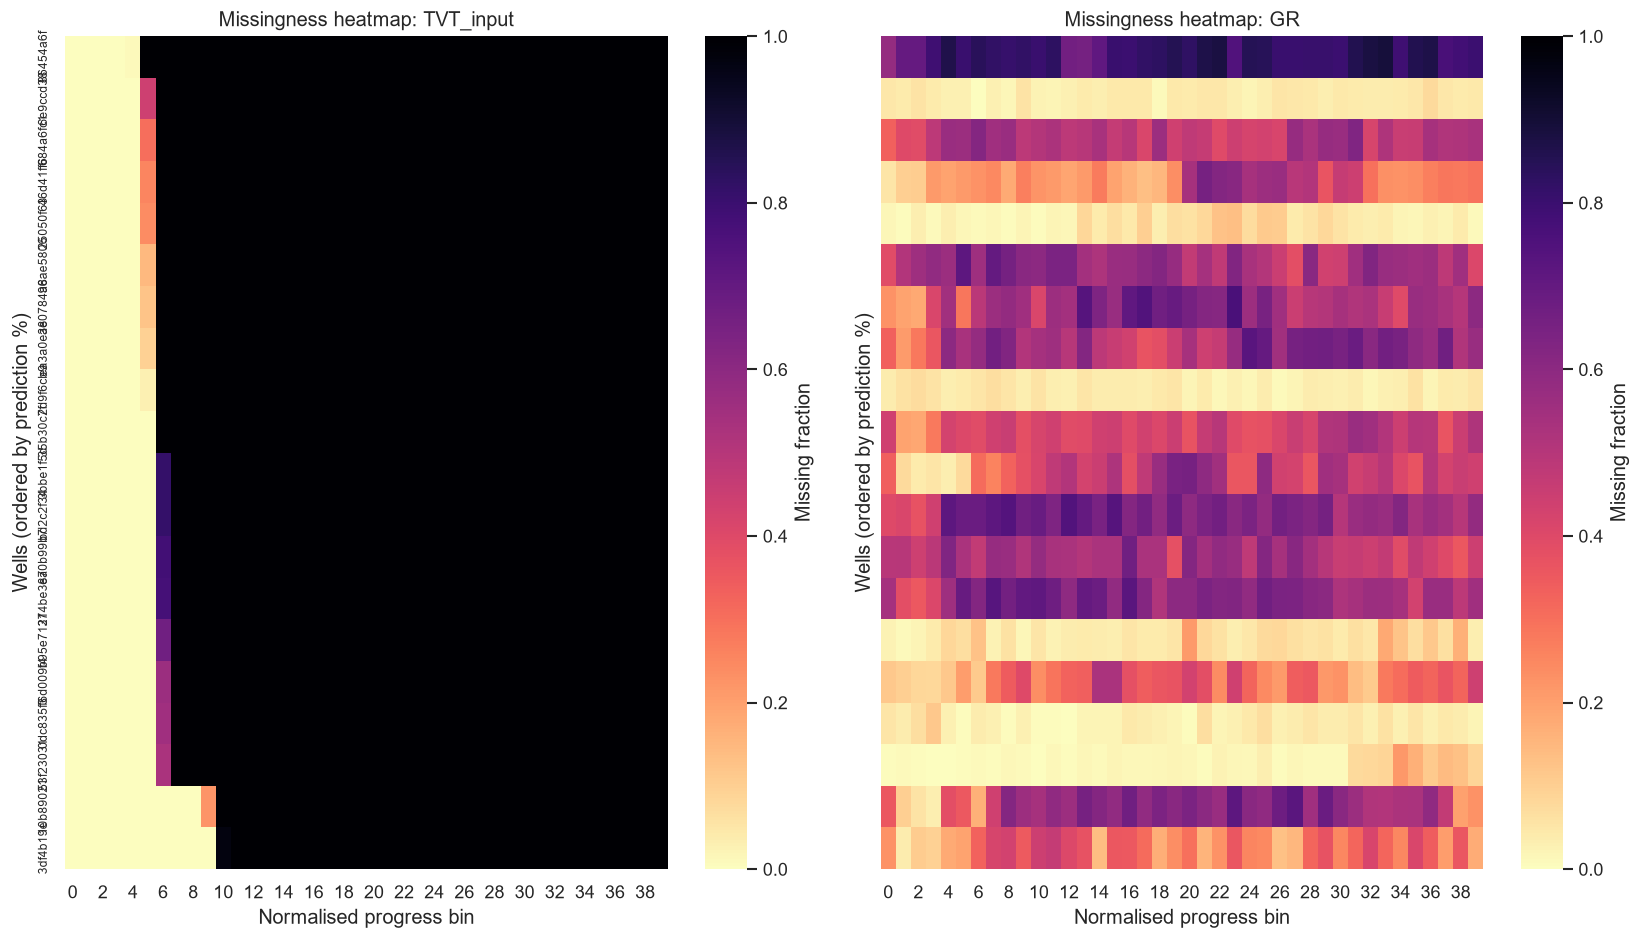

,Variable,Wells_Affected,Median_Missing_Pct_Among_Affected,Max_Missing_Pct,Median_Longest_Run_Rows,Pattern
0,TVT_input (prediction mask),773,73.9991,87.5165,"4,840.0000",Primarily trailing contiguous blocks
1,GR,773,27.7038,80.0989,13.0000,Mixed blocks and irregular gaps
2,Typewell Geology,713,36.6941,66.4043,NaN,Label incompleteness on typewell


In [59]:
def missingness_profile(well_id, n_bins=40):
    df = pd.read_csv(horizontal_map[well_id])
    progress = np.linspace(0, 1, len(df), endpoint=False)
    bin_ids = np.minimum((progress * n_bins).astype(int), n_bins - 1)
    cols = ["TVT_input", "GR"]
    cols += [c for c in FORMATION_COLUMNS if c in df.columns and df[c].isna().any()]
    records = {"Well_ID": well_id}
    for col in cols:
        missing = df[col].isna().to_numpy()
        for b in range(n_bins):
            mask = bin_ids == b
            records[f"{col}_bin{b}"] = missing[mask].mean() if mask.any() else np.nan
    return records, cols

heatmap_wells = selected_wells["Well_ID"].tolist()
extra_n = 17
extra_wells = (
    well_summary.sort_values("Prediction_Percentage", ascending=False)["Well_ID"]
    .head(extra_n + 3)
    .tolist()
)
for well_id in extra_wells:
    if well_id not in heatmap_wells:
        heatmap_wells.append(well_id)
    if len(heatmap_wells) >= 3 + extra_n:
        break

# Order by prediction percentage
order = (
    well_summary.set_index("Well_ID")
    .loc[heatmap_wells]
    .sort_values("Prediction_Percentage", ascending=False)
    .index.tolist()
)

n_bins = 40
profiles = []
feature_set = None
for well_id in order:
    rec, cols = missingness_profile(well_id, n_bins=n_bins)
    profiles.append(rec)
    feature_set = cols

# Build separate heatmaps for TVT_input and GR
def matrix_for(feature):
    mat = []
    for rec in profiles:
        mat.append([rec.get(f"{feature}_bin{b}", np.nan) for b in range(n_bins)])
    return np.array(mat, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
for ax, feature in zip(axes, ["TVT_input", "GR"]):
    mat = matrix_for(feature)
    sns.heatmap(mat, ax=ax, cmap="magma_r", vmin=0, vmax=1, cbar_kws={"label": "Missing fraction"})
    ax.set_title(f"Missingness heatmap: {feature}")
    ax.set_xlabel("Normalised progress bin")
    ax.set_ylabel("Wells (ordered by prediction %)")
    ax.set_yticks(np.arange(len(order)) + 0.5)
    ax.set_yticklabels(order, fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "missingness_heatmap_normalised_progress.png", bbox_inches="tight")
plt.show()

# Variable-level missingness stats from well_summary + runs
missing_stats = pd.DataFrame(
    [
        {
            "Variable": "TVT_input (prediction mask)",
            "Wells_Affected": int((well_summary["Prediction_Rows"] > 0).sum()),
            "Median_Missing_Pct_Among_Affected": well_summary.loc[
                well_summary["Prediction_Rows"] > 0, "Prediction_Percentage"
            ].median(),
            "Max_Missing_Pct": well_summary["Prediction_Percentage"].max(),
            "Median_Longest_Run_Rows": well_summary["Prediction_Rows"].median(),
            "Pattern": "Primarily trailing contiguous blocks",
        },
        {
            "Variable": "GR",
            "Wells_Affected": int((well_summary["GR_Missing_Percentage"] > 0).sum()),
            "Median_Missing_Pct_Among_Affected": well_summary.loc[
                well_summary["GR_Missing_Percentage"] > 0, "GR_Missing_Percentage"
            ].median(),
            "Max_Missing_Pct": well_summary["GR_Missing_Percentage"].max(),
            "Median_Longest_Run_Rows": well_summary["Longest_GR_Missing_Run"].median(),
            "Pattern": "Mixed blocks and irregular gaps",
        },
        {
            "Variable": "Typewell Geology",
            "Wells_Affected": int((well_summary["Geology_Missing_Percentage"] > 0).sum()),
            "Median_Missing_Pct_Among_Affected": well_summary.loc[
                well_summary["Geology_Missing_Percentage"] > 0, "Geology_Missing_Percentage"
            ].median(),
            "Max_Missing_Pct": well_summary["Geology_Missing_Percentage"].max(),
            "Median_Longest_Run_Rows": np.nan,
            "Pattern": "Label incompleteness on typewell",
        },
    ]
)
display(missing_stats)
missing_stats.to_csv(TABLES_DIR / "missingness_variable_summary.csv", index=False)


**Interpretation.** The heatmaps show `TVT_input` missingness concentrating in
late progress bins (systematic trailing blocks), whereas GR missingness is more
irregular across progress. This distinction should drive different preprocessing:
preserve the `TVT_input` mask; treat GR gaps as ordinary incompleteness.


### 26. Target and Prediction-Horizon Analysis

Quantify per-well TVT ranges, last-known to final changes, horizon lengths and
approximate TVT change per MD. This helps explain when a last-known-value
baseline may perform well or poorly. Associations are descriptive, not causal.


,count,mean,std,min,25%,50%,75%,max
Horizontal_TVT_Min,773.0000,"10,834.3489",635.4178,"9,245.1900","10,353.0600","10,650.9000","11,358.2700","12,444.0800"
Horizontal_TVT_Max,773.0000,"11,568.8178",620.0407,"10,072.1800","11,052.4500","11,384.6300","12,067.5100","12,893.8900"
Horizontal_TVT_Range,773.0000,734.4689,175.4844,158.9300,588.5700,758.2200,856.5100,"1,256.7000"
Last_Known_TVT,773.0000,"11,551.0561",619.9044,"10,055.2600","11,031.3300","11,368.7100","12,055.5400","12,873.0700"
Final_TVT,773.0000,"11,552.0407",619.8722,"10,050.8100","11,036.2300","11,367.5000","12,051.6600","12,880.9000"
Delta_TVT_LastKnown_to_Final,773.0000,0.9846,20.5840,-103.7800,-9.5000,1.4000,12.0000,89.7400
Abs_Delta_TVT,773.0000,14.7805,14.3501,0.0000,5.3900,10.9700,19.4900,103.7800
Prediction_Rows,773.0000,"4,895.1992","1,301.1784",407.0000,"4,044.0000","4,840.0000","5,694.0000","10,052.0000"
Prediction_Horizon_MD,773.0000,"4,894.1992","1,301.1784",406.0000,"4,043.0000","4,839.0000","5,693.0000","10,051.0000"
Prediction_Percentage,773.0000,73.3161,6.3776,19.7765,70.0344,73.9991,77.5462,87.5165


Percentiles of Abs_Delta_TVT:


,Abs_Delta_TVT
0.5000,10.9700
0.7500,19.4900
0.9000,31.9560
0.9500,41.2940
0.9900,73.2572


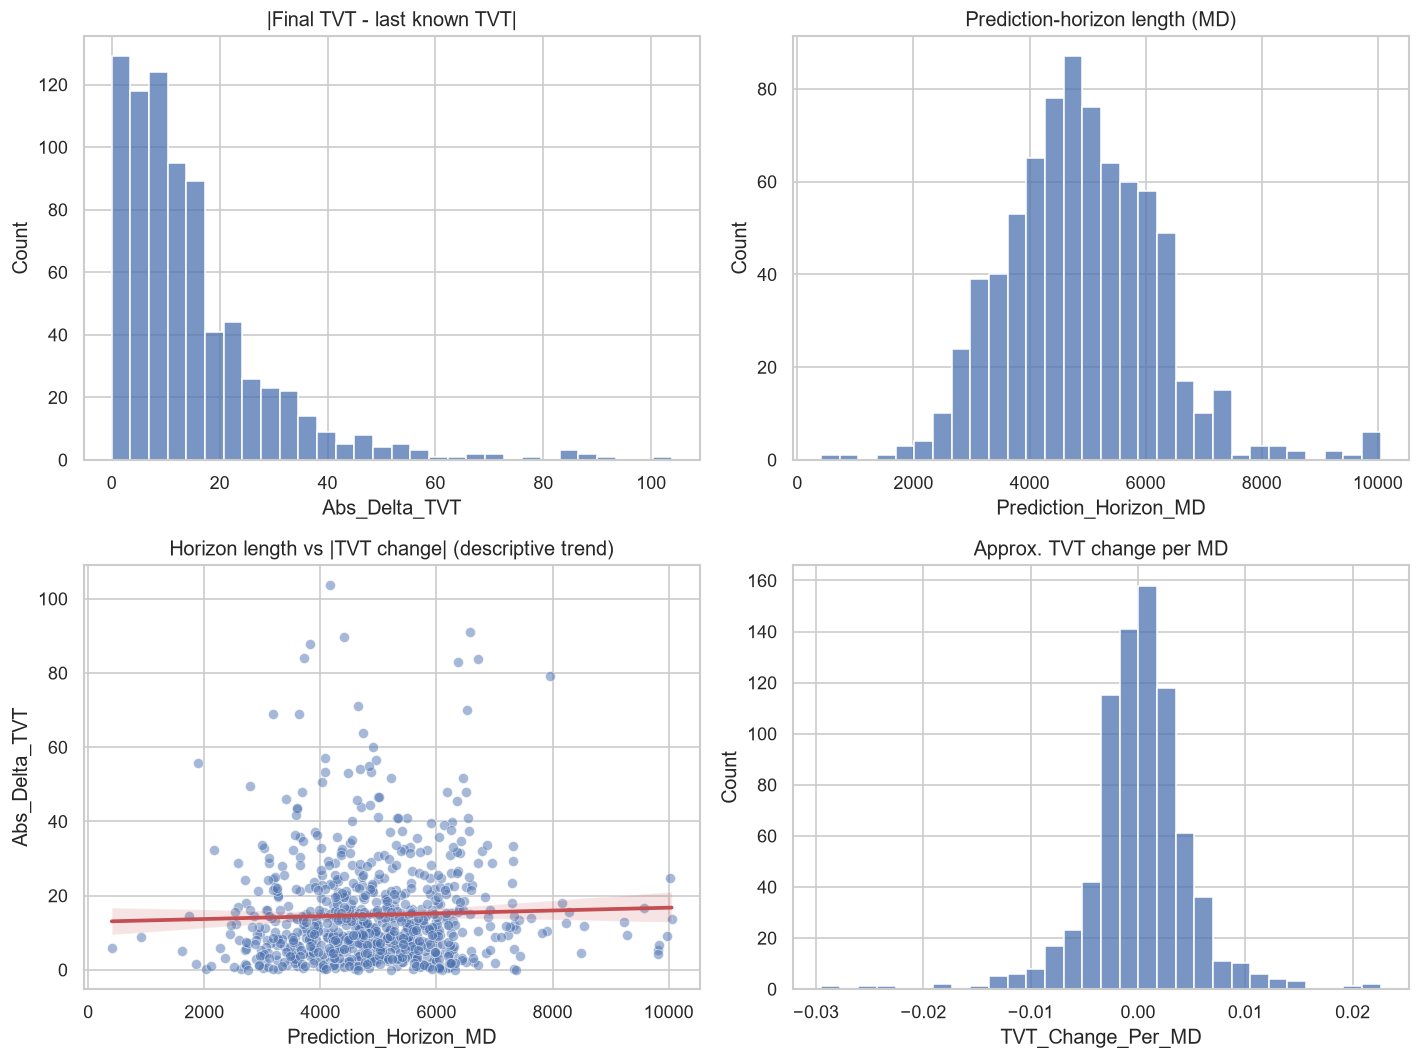

Pearson corr(horizon MD, |delta TVT|): 0.035


In [60]:
horizon = well_summary[
    [
        "Well_ID",
        "Horizontal_TVT_Min",
        "Horizontal_TVT_Max",
        "Horizontal_TVT_Range",
        "Last_Known_TVT",
        "Final_TVT",
        "Delta_TVT_LastKnown_to_Final",
        "Abs_Delta_TVT",
        "Prediction_Rows",
        "Prediction_Horizon_MD",
        "Prediction_Percentage",
        "TVT_Change_Per_MD",
        "Prefix_Slope_Last_50",
        "Prefix_Slope_Last_100",
    ]
].copy()

display(horizon.describe(include=[np.number]).T)
print("Percentiles of Abs_Delta_TVT:")
display(horizon["Abs_Delta_TVT"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("Abs_Delta_TVT"))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(horizon["Abs_Delta_TVT"].dropna(), bins=30, ax=axes[0, 0])
axes[0, 0].set_title("|Final TVT - last known TVT|")
sns.histplot(horizon["Prediction_Horizon_MD"].dropna(), bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Prediction-horizon length (MD)")
sns.scatterplot(
    data=horizon,
    x="Prediction_Horizon_MD",
    y="Abs_Delta_TVT",
    ax=axes[1, 0],
    alpha=0.5,
)
sns.regplot(
    data=horizon,
    x="Prediction_Horizon_MD",
    y="Abs_Delta_TVT",
    ax=axes[1, 0],
    scatter=False,
    color="C3",
)
axes[1, 0].set_title("Horizon length vs |TVT change| (descriptive trend)")
sns.histplot(horizon["TVT_Change_Per_MD"].dropna(), bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Approx. TVT change per MD")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "prediction_horizon_analysis.png", bbox_inches="tight")
plt.show()

horizon.to_csv(TABLES_DIR / "prediction_horizon_metrics.csv", index=False)
corr_horizon = horizon[["Prediction_Horizon_MD", "Abs_Delta_TVT"]].corr().iloc[0, 1]
print("Pearson corr(horizon MD, |delta TVT|):", round(float(corr_horizon), 3))


**Interpretation.** Wells differ widely in |final TVT − last known TVT| and
horizon length. A positive descriptive association would suggest longer horizons
often coincide with larger TVT changes, which can degrade a last-known-value
baseline. The trend is not causal. Models and validation should stratify by
horizon difficulty.


### 27. Typewell Coverage vs Horizontal Requirements

Compare typewell TVT ranges with horizontal and prediction-region TVT ranges.
Insufficient coverage implies interpolation limits and possible extrapolation,
which can make geological matching harder.


,Coverage_Category,Well_Count,Percentage
0,complete,773,100.0000


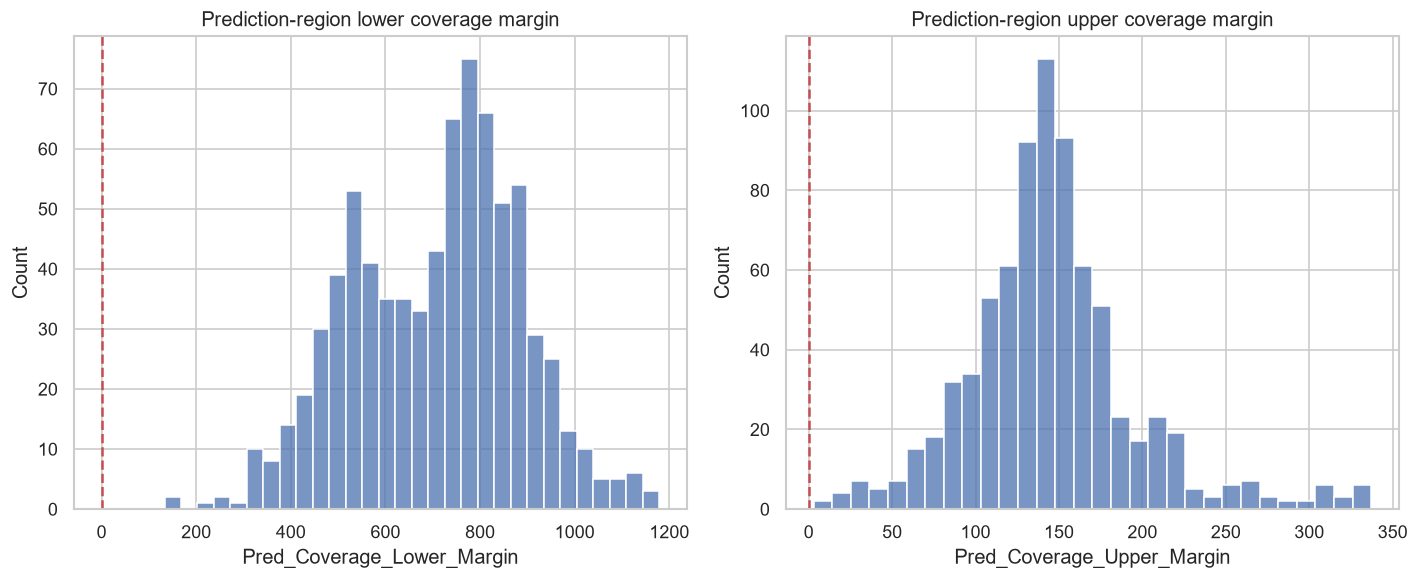

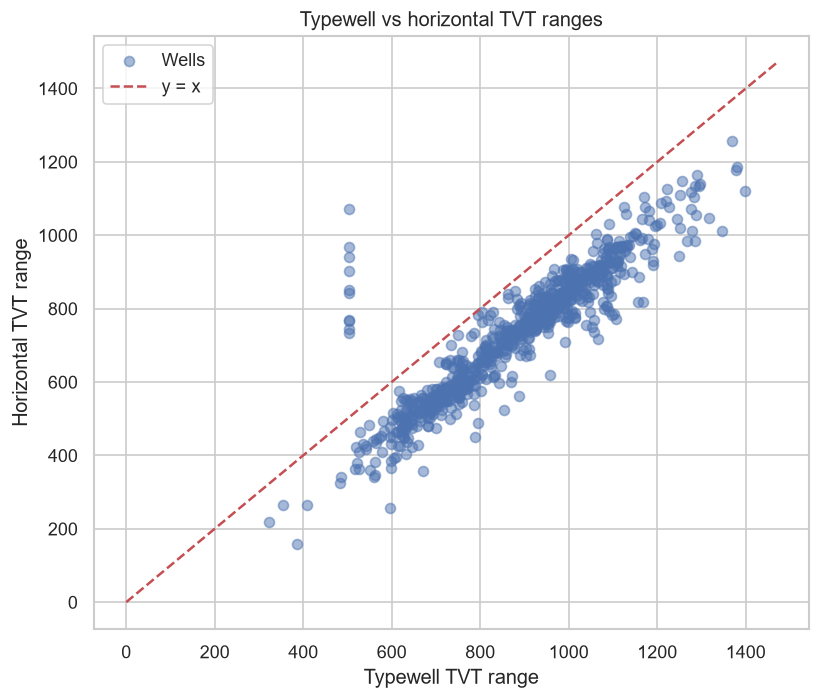

,Well_ID,Coverage_Category,Typewell_TVT_Min,Typewell_TVT_Max,Pred_Region_TVT_Min,Pred_Region_TVT_Max,Pred_Coverage_Lower_Margin,Pred_Coverage_Upper_Margin


In [61]:
coverage_counts = (
    well_summary["Coverage_Category"]
    .value_counts(dropna=False)
    .rename_axis("Coverage_Category")
    .reset_index(name="Well_Count")
)
coverage_counts["Percentage"] = 100 * coverage_counts["Well_Count"] / len(well_summary)
display(coverage_counts)
coverage_counts.to_csv(TABLES_DIR / "typewell_coverage_categories.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(well_summary["Pred_Coverage_Lower_Margin"].dropna(), bins=30, ax=axes[0])
axes[0].axvline(0, color="C3", ls="--")
axes[0].set_title("Prediction-region lower coverage margin")
sns.histplot(well_summary["Pred_Coverage_Upper_Margin"].dropna(), bins=30, ax=axes[1])
axes[1].axvline(0, color="C3", ls="--")
axes[1].set_title("Prediction-region upper coverage margin")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "typewell_coverage_margins.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    well_summary["Typewell_TVT_Range"],
    well_summary["Horizontal_TVT_Range"],
    alpha=0.5,
    label="Wells",
)
lims = [
    0,
    max(
        well_summary["Typewell_TVT_Range"].max(),
        well_summary["Horizontal_TVT_Range"].max(),
    )
    * 1.05,
]
ax.plot(lims, lims, ls="--", color="C3", label="y = x")
ax.set_xlabel("Typewell TVT range")
ax.set_ylabel("Horizontal TVT range")
ax.set_title("Typewell vs horizontal TVT ranges")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "typewell_vs_horizontal_tvt_ranges.png", bbox_inches="tight")
plt.show()

problem_wells = well_summary.loc[
    well_summary["Coverage_Category"] != "complete"
].sort_values("Prediction_Percentage", ascending=False)

display(problem_wells[
    [
        "Well_ID",
        "Coverage_Category",
        "Typewell_TVT_Min",
        "Typewell_TVT_Max",
        "Pred_Region_TVT_Min",
        "Pred_Region_TVT_Max",
        "Pred_Coverage_Lower_Margin",
        "Pred_Coverage_Upper_Margin",
    ]
].head(15))

# Detailed plots for up to 3 problematic wells
plot_ids = problem_wells["Well_ID"].head(3).tolist()
if plot_ids:
    fig, axes = plt.subplots(len(plot_ids), 1, figsize=(10, 4 * len(plot_ids)), sharex=False)
    if len(plot_ids) == 1:
        axes = [axes]
    for ax, well_id in zip(axes, plot_ids):
        tw = pd.read_csv(typewell_map[well_id])
        hz = pd.read_csv(horizontal_map[well_id])
        ax.hist(tw["TVT"], bins=40, density=True, alpha=0.4, label="Typewell TVT")
        ax.hist(hz["TVT"], bins=40, density=True, alpha=0.4, label="Horizontal TVT")
        ax.axvline(tw["TVT"].min(), color="C0", ls="--")
        ax.axvline(tw["TVT"].max(), color="C0", ls="--")
        ax.set_title(f"Coverage problem well {well_id}")
        ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "typewell_coverage_problem_wells.png", bbox_inches="tight")
    plt.show()


**Interpretation.** Most wells have complete typewell coverage of prediction
region TVT, but partial or absent coverage occurs for a minority. Negative
margins imply extrapolation beyond the typewell TVT range, which can impair
geological matching. Those wells deserve closer inspection during validation.


### 28. Outlier and Data-Quality Screening

Flag extreme wells using percentiles and IQR rules without deleting or capping
values. Distinguish probable data issues from extreme but plausible geological
or operational variation.


,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900
Horizontal_Rows,"3,778.8000","4,652.2000","5,706.0000","6,576.0000","7,388.0000","8,614.2000","11,031.6800"
Prediction_Horizon_MD,"2,156.2000","2,946.4000","4,043.0000","4,839.0000","5,693.0000","6,917.4000","9,250.8800"
Prediction_Percentage,56.7313,62.4709,70.0344,73.9991,77.5462,81.9461,85.1065
GR_Missing_Percentage,1.8806,3.7823,12.1198,27.7038,46.3952,60.3280,65.7472
Horizontal_TVT_Range,345.2284,449.2920,588.5700,758.2200,856.5100,996.9840,"1,127.7612"
Abs_Delta_TVT,0.1072,0.9740,5.3900,10.9700,19.4900,41.2940,73.2572
TVT_Change_Per_MD,-0.0132,-0.0072,-0.0020,0.0003,0.0025,0.0068,0.0127
Longest_GR_Missing_Run,2.0000,3.0000,8.0000,13.0000,19.0000,144.4000,246.5200
Pred_Coverage_Lower_Margin,323.5692,413.0280,562.9200,743.2800,835.9800,978.7560,"1,120.1944"
Pred_Coverage_Upper_Margin,29.2732,68.4920,118.4600,141.8900,167.3100,234.7600,318.2976


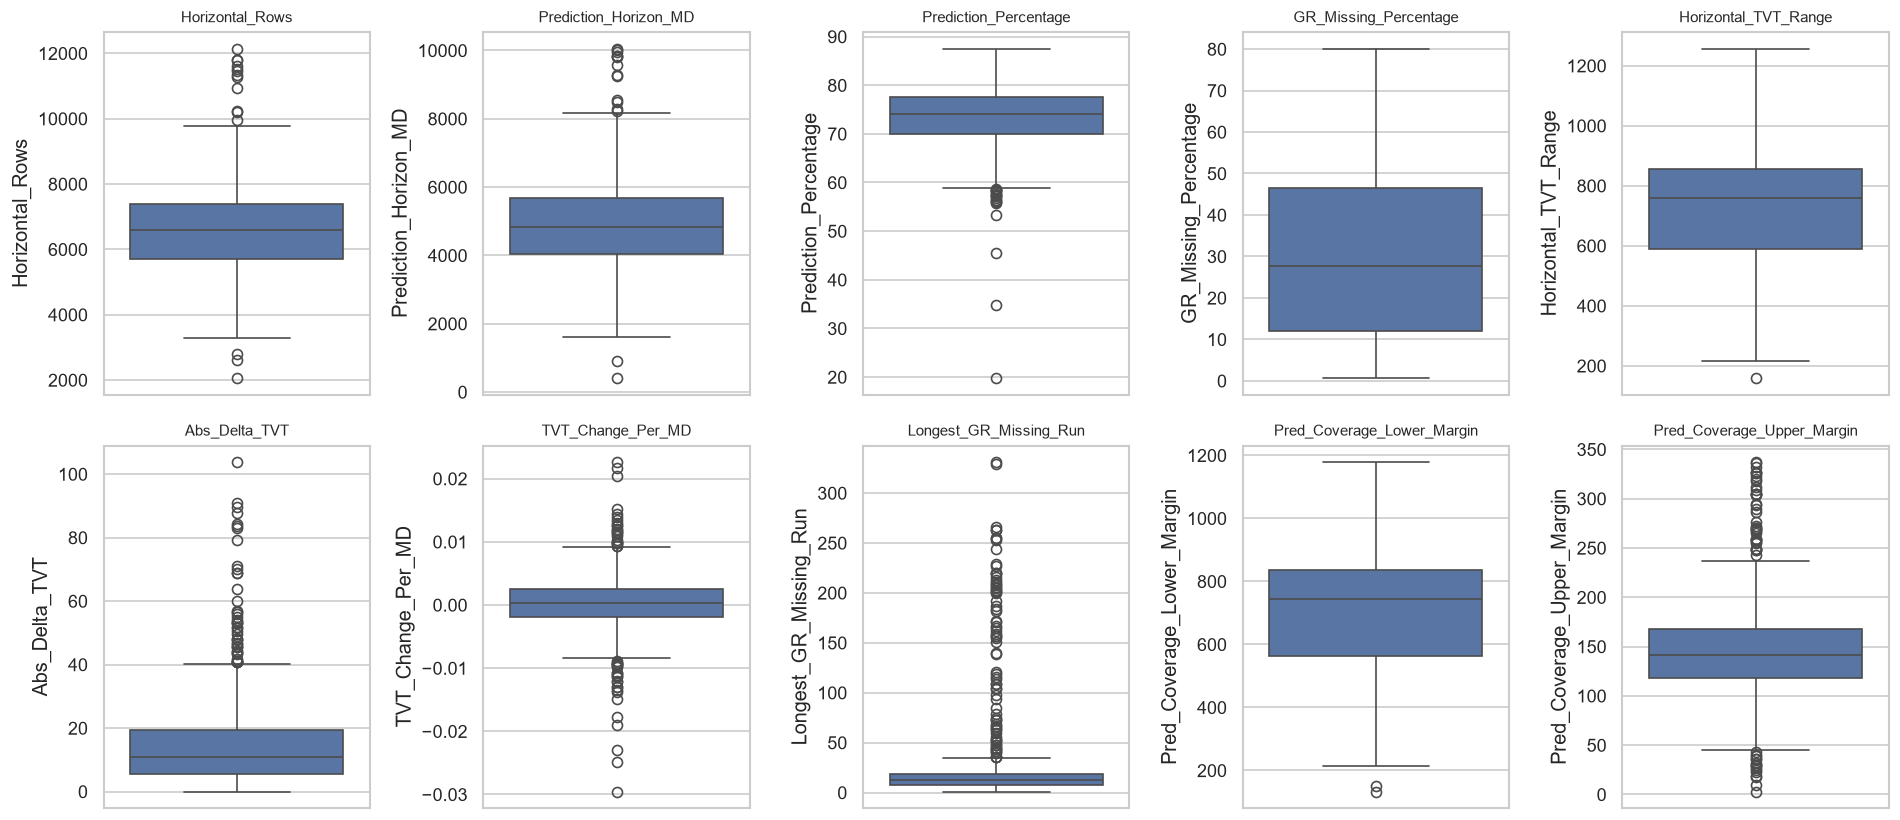

,Well_ID,IQR_Outlier_Count,Coverage_Issue,Internal_Gap_Flag,Horizontal_Rows,Prediction_Percentage,Prediction_Horizon_MD,GR_Missing_Percentage,Abs_Delta_TVT,Coverage_Category
0,404c4384,4,False,False,2612,34.8775,910.0000,19.7167,8.9000,complete
1,fba7683c,4,False,False,2058,19.7765,406.0000,2.0408,5.8400,complete
2,46a301e9,3,False,False,9962,82.5738,"8,225.0000",43.9771,12.5200,complete
3,86454a6f,3,False,False,9100,87.5165,"7,963.0000",80.0989,79.1900,complete
4,96ae5806,3,False,False,11527,85.3561,"9,838.0000",55.2182,6.6200,complete
5,a783cc24,3,False,False,3275,57.6794,"1,888.0000",10.3511,55.7800,complete
6,cf50c9d1,3,False,False,6634,73.2288,"4,857.0000",17.1088,44.4000,complete
7,d90aa14c,3,False,False,12141,82.5138,"10,017.0000",40.3426,24.8500,complete
8,d924e971,3,False,False,5308,59.9849,"3,183.0000",10.8139,68.8700,complete
9,e5864244,3,False,False,6037,74.0268,"4,468.0000",33.2781,53.0100,complete


Note: IQR flags are screening tools. Extreme prediction horizons or TVT ranges may be geologically plausible. Internal gaps or schema issues are more suggestive of data-quality problems.


In [62]:
outlier_metrics = [
    "Horizontal_Rows",
    "Prediction_Horizon_MD",
    "Prediction_Percentage",
    "GR_Missing_Percentage",
    "Horizontal_TVT_Range",
    "Abs_Delta_TVT",
    "TVT_Change_Per_MD",
    "Longest_GR_Missing_Run",
    "Pred_Coverage_Lower_Margin",
    "Pred_Coverage_Upper_Margin",
]


def iqr_flags(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper


percentile_table = well_summary[outlier_metrics].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
display(percentile_table)
percentile_table.to_csv(TABLES_DIR / "outlier_percentiles.csv")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()
for ax, col in zip(axes, outlier_metrics):
    sns.boxplot(y=well_summary[col], ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "outlier_boxplots.png", bbox_inches="tight")
plt.show()

flag_matrix = pd.DataFrame({"Well_ID": well_summary["Well_ID"]})
for col in outlier_metrics:
    flags, lower, upper = iqr_flags(well_summary[col])
    flag_matrix[f"{col}_IQR_outlier"] = flags.to_numpy()

flag_matrix["IQR_Outlier_Count"] = flag_matrix.filter(like="_IQR_outlier").sum(axis=1)
flag_matrix["Coverage_Issue"] = well_summary["Coverage_Category"].ne("complete").to_numpy()
flag_matrix["Internal_Gap_Flag"] = well_summary["Unexpected_Internal_Gaps"].to_numpy()

review_wells = flag_matrix.sort_values(
    ["IQR_Outlier_Count", "Coverage_Issue"],
    ascending=False,
).head(25)

review_detail = review_wells.merge(well_summary, on="Well_ID", how="left")
display(review_detail[
    [
        "Well_ID",
        "IQR_Outlier_Count",
        "Coverage_Issue",
        "Internal_Gap_Flag",
        "Horizontal_Rows",
        "Prediction_Percentage",
        "Prediction_Horizon_MD",
        "GR_Missing_Percentage",
        "Abs_Delta_TVT",
        "Coverage_Category",
    ]
])
review_detail.to_csv(TABLES_DIR / "outlier_review_wells.csv", index=False)
flag_matrix.to_csv(TABLES_DIR / "outlier_flags_by_well.csv", index=False)

print(
    "Note: IQR flags are screening tools. Extreme prediction horizons or TVT "
    "ranges may be geologically plausible. Internal gaps or schema issues are "
    "more suggestive of data-quality problems."
)


**Interpretation.** A minority of wells are extreme on multiple metrics and
should be reviewed during model validation. The analysis does not delete
outliers. Extreme horizons or TVT changes may be operationally real, whereas
internal `TVT_input` gaps would be more concerning. Grouped validation should
include these wells rather than hide them via row shuffling.


### 29. Save the Dataset-Wide Summary

Persist the extended well-level summary for reuse by later notebooks, and write
key tables under `results/notebook_03/`.


In [63]:
summary_output_path = PROCESSED_DIR / "training_well_summary.csv"
well_summary.to_csv(summary_output_path, index=False)
well_summary.to_csv(TABLES_DIR / "training_well_summary.csv", index=False)
print("Summary saved to:", summary_output_path.resolve())
print("Also saved to:", (TABLES_DIR / "training_well_summary.csv").resolve())
print("Summary shape:", well_summary.shape)


Summary saved to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed\training_well_summary.csv
Also saved to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_03\tables\training_well_summary.csv
Summary shape: (773, 58)


### 30. Confirm the Saved File


In [64]:
saved_summary = pd.read_csv(summary_output_path)
print("Saved summary shape:", saved_summary.shape)
print("Well IDs with trailing underscore:", saved_summary["Well_ID"].astype(str).str.endswith("_").sum())
display(saved_summary.head())
assert saved_summary["Well_ID"].astype(str).str.endswith("_").sum() == 0


Saved summary shape: (773, 58)
Well IDs with trailing underscore: 0


,Well_ID,Typewell_Rows,Horizontal_Rows,Known_Rows,Prediction_Rows,Prediction_Percentage,Prediction_Start_MD,Last_Known_MD,Last_Known_TVT,Final_TVT,Delta_TVT_LastKnown_to_Final,Abs_Delta_TVT,Prediction_Horizon_MD,TVT_Change_Per_MD,Clean_Prediction_Boundary,Unexpected_Internal_Gaps,TVT_Input_Matches_TVT,MD_Min,MD_Max,Median_MD_Step,MD_Is_Monotonic,X_Min,X_Max,Y_Min,Y_Max,Z_Min,Z_Max,Typewell_TVT_Min,Typewell_TVT_Max,Typewell_TVT_Range,Typewell_GR_Min,Typewell_GR_Max,Median_Typewell_TVT_Step,Typewell_TVT_Is_Monotonic,Horizontal_TVT_Min,Horizontal_TVT_Max,Horizontal_TVT_Range,Pred_Region_TVT_Min,Pred_Region_TVT_Max,Coverage_Lower_Margin,Coverage_Upper_Margin,Pred_Coverage_Lower_Margin,Pred_Coverage_Upper_Margin,Typewell_Covers_Horizontal_TVT,Typewell_Covers_Prediction_TVT,Coverage_Category,GR_Missing_Percentage,Prediction_GR_Missing_Percentage,Longest_GR_Missing_Run,Geology_Missing_Percentage,Formation_Missing_Percentage,Z_TVT_Correlation,GR_TVT_Correlation,Prefix_Slope_Last_10,Prefix_Slope_Last_50,Prefix_Slope_Last_100,Typewell_Duplicate_Rows,Horizontal_Duplicate_Rows
0,000d7d20,1296,5278,1442,3836,72.6790,"12,909.0000","12,908.0000","11,747.3700","11,737.3100",-10.0600,10.0600,"3,835.0000",-0.0026,True,False,True,"11,467.0000","16,744.0000",1.0000,True,"2,983,468.4100","2,983,578.2800","1,069,022.0900","1,074,040.5600","-9,755.6100","-9,258.5700","11,223.9500","11,871.4500",647.5000,28.6600,158.1800,0.5000,True,"11,236.0200","11,756.1200",520.1000,"11,734.8300","11,750.0300",12.0700,115.3300,510.8800,121.4200,True,True,complete,42.7814,47.3410,19,23.0710,0.0000,-0.9177,0.0011,0.0113,0.0167,0.0125,0,0
1,00bbac68,1946,7559,1545,6014,79.5608,"13,123.0000","13,122.0000","12,223.5400","12,216.8000",-6.7400,6.7400,"6,013.0000",-0.0011,True,False,True,"11,578.0000","19,136.0000",1.0000,True,"3,005,789.1500","3,010,760.0800","1,084,504.4400","1,089,521.3600","-10,182.5800","-9,436.3600","11,394.4500","12,366.9500",972.5000,31.8600,215.4400,0.5000,True,"11,406.6300","12,240.0100",833.3800,"12,189.8200","12,240.0100",12.1800,126.9400,795.3700,126.9400,True,True,complete,12.4620,13.8344,8,47.3792,0.0000,-0.9076,-0.2420,0.0170,0.0131,0.0076,0,0
2,00e12e8b,2556,6384,2083,4301,67.3716,"12,539.0000","12,538.0000","11,604.8200","11,596.3700",-8.4500,8.4500,"4,300.0000",-0.0020,True,False,True,"10,456.0000","16,839.0000",1.0000,True,"2,967,726.4900","2,971,071.9800","1,060,431.2300","1,065,106.5000","-9,338.3400","-8,356.0400","10,593.9500","11,871.4500","1,277.5000",28.6600,195.4200,0.5000,True,"10,606.1800","11,616.6400","1,010.4600","11,587.0500","11,616.6400",12.2300,254.8100,993.1000,254.8100,True,True,complete,9.1479,9.7187,8,60.9937,0.0000,-0.9639,-0.7860,0.0415,0.0421,0.0367,0,0
3,015fe0d2,1265,5950,1654,4296,72.2017,"13,488.0000","13,487.0000","12,233.7800","12,257.7600",23.9800,23.9800,"4,295.0000",0.0056,True,False,True,"11,834.0000","17,783.0000",1.0000,True,"2,998,620.5000","3,002,003.0900","1,073,179.4500","1,077,773.5300","-10,231.8500","-9,537.6600","11,734.9500","12,366.9500",632.0000,31.8600,215.4400,0.5000,True,"11,747.2600","12,271.5300",524.2700,"12,232.9200","12,271.5300",12.3100,95.4200,497.9700,95.4200,True,True,complete,25.4286,32.0298,9,19.0514,0.0000,-0.9283,0.2037,0.0295,0.0299,0.0259,0,0
4,01869cd4,1052,6850,1293,5557,81.1241,"12,549.0000","12,548.0000","11,745.9400","11,749.3900",3.4500,3.4500,"5,556.0000",0.0006,True,False,True,"11,256.0000","18,105.0000",1.0000,True,"2,971,669.4000","2,975,650.0900","1,063,180.3100","1,068,509.1200","-9,643.3500","-8,961.3900","11,345.9500","11,871.4500",525.5000,28.6600,145.2100,0.5000,True,"11,358.2700","11,767.7500",409.4800,"11,728.7500","11,767.7500",12.3200,103.7000,382.8000,103.7000,True,True,complete,47.7080,51.1247,14,5.2281,0.0000,-0.8800,0.0651,0.0010,0.0085,0.0149,0,0


### 31. Dataset-Wide EDA Conclusions

- **Scale and pairing.** Hundreds of matched training pairs and only a few test
  pairs form the corpus; training horizontal data comprise millions of rows with
  a large prediction-region share.
- **Intentional `TVT_input` missingness.** Across wells, `TVT_input` is present
  in a known prefix and missing in a trailing prediction block. This is a task
  mask, not accidental missing data, and should not be mean/median imputed.
  Known-row equality with `TVT` is expected by construction.
- **Ordinary missingness.** GR and typewell geology show ordinary incompleteness
  that varies by well and is often irregular rather than strictly trailing.
- **Depth and spatial structure.** Trajectory and formation markers exhibit
  strong mutual associations and often strong links with TVT; these are
  descriptive linear patterns, not causal proof of feature usefulness.
- **Between-well variation.** Row counts, prediction percentages, GR gaps and
  TVT behaviour differ widely; a single well is not representative.
- **Prediction-horizon difficulty.** Longer horizons and larger |final − last
  known| TVT changes identify settings where last-known baselines may degrade.
- **Typewell coverage.** Most wells have complete coverage of prediction-region
  TVT, but partial/none coverage implies interpolation/extrapolation risk.
- **Train–test differences.** With few test wells, distribution-shift evidence is
  provisional and must not be overinterpreted from row-level KS tests.
- **Outliers and difficult wells.** IQR screening highlights wells for closer
  validation without automatic deletion.
- **Validation risk.** Random row-level splits ignore within-well dependence and
  can leak well-specific structure; grouped, well-level validation is required.
- **Implications.** Preserve the `TVT_input` mask; engineer relative-depth and
  typewell-matching features carefully; evaluate with GroupKFold-style schemes;
  include long-horizon and coverage-challenged wells in error analysis.

This EDA does not select a final machine-learning model. It only identifies
evidence that should guide later preprocessing, feature engineering, modelling
and validation.
